# Capstone: Bayesian Optimisation

The pipeline engine and every diagnostic plot now live in `bbo_pipeline.py` / `bbo_data.py` / `bbo_diagnostics.py`. This notebook only sequences calls into them.

For definitions, please refer to the glossary section at the end.

## Setup

Import all the libraries and files.

The three project modules, `bd`, `bp`, and `bdiag`, contain all data-loading, GP/Bayesian-optimisation, and diagnostic/plotting logic respectively. This notebook is therefore limited to sequencing calls to these modules; no pipeline logic should be implemented here.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

import bbo_data as bd
import bbo_pipeline as bp
import bbo_diagnostics as bdiag

Load the initial per-function samples plus everything appended since from `inputs_W12.txt`/`outputs_W12.txt`.

Sample sizes range from 22 points for F1 and F2, each two-dimensional, to 52 points for F8, which is eight-dimensional. Dimensionality and sample budget generally increase together, although not strictly proportionally. E.g. F4 already has 42 points despite having only four dimensions.

In [2]:
all_X, all_y, X1,y1,X2,y2,X3,y3,X4,y4,X5,y5,X6,y6,X7,y7,X8,y8 = bd.load_all_individual()
for fn in range(1, 9):
    print(f"F{fn}: X{all_X[fn-1].shape}  y{all_y[fn-1].shape}")

F1: X(22, 2)  y(22,)
F2: X(22, 2)  y(22,)
F3: X(27, 3)  y(27,)
F4: X(42, 4)  y(42,)
F5: X(32, 4)  y(32,)
F6: X(32, 5)  y(32,)
F7: X(42, 6)  y(42,)
F8: X(52, 8)  y(52,)


Obtain the recommendation for warping strategy for each function through LOO-CV and update the `CONFIG` section for each function in `bbo_pipeline.py`

The comparison identifies functions for which a change of warp strategy is clearly justified, based on three metrics (R², trim1, and rho). For F1, `yeo` produces the least unfavourable result of the three options (R² = -0.047, compared with -0.644 for `None` and -0.537 for `log`), but this should not be regarded as a genuine improvement in fit, given the untrustworthy nature of the GP. For all functions, the `warp` strategy has been set as per the recommendation from this comparison. 

In [3]:
df_warp = bdiag.compare_warps(all_X, all_y)


--- F1 (current: warp=yeo) ---
  warp=None    R2=-0.644  trim1=-10680.205  rho=-0.187
  warp=log     R2=-0.537  trim1=-8768.881  rho=-0.187
  warp=yeo     R2=-0.047  trim1=-38.143  rho=+0.085

--- F2 (current: warp=log) ---
  warp=None    R2=+0.427  trim1=+0.558  rho=+0.697
  warp=log     R2=+0.559  trim1=+0.655  rho=+0.737
  warp=yeo     R2=+0.404  trim1=+0.532  rho=+0.688

--- F3 (current: warp=yeo) ---
  warp=None    R2=+0.217  trim1=+0.340  rho=+0.842
  warp=log     R2=+0.183  trim1=+0.228  rho=+0.835
  warp=yeo     R2=+0.336  trim1=+0.740  rho=+0.876

--- F4 (current: warp=None) ---
  warp=None    R2=+0.924  trim1=+0.938  rho=+0.951
  warp=log     R2=+0.863  trim1=+0.901  rho=+0.934
  warp=yeo     R2=+0.847  trim1=+0.876  rho=+0.919

--- F5 (current: warp=None) ---
  warp=None    R2=+0.933  trim1=+0.973  rho=+0.699
  warp=log     R2=+0.853  trim1=+0.957  rho=+0.611
  warp=yeo     R2=+0.890  trim1=+0.970  rho=+0.665

--- F6 (current: warp=None) ---
  warp=None    R2=+0.752  trim1=

function,current_warp,None_R2,log_R2,yeo_R2,best_by_R2,recommendation
1,yeo,-0.644,-0.537,-0.047,yeo,KEEP (yeo)
2,log,+0.427,+0.559,+0.404,log,KEEP (log)
3,yeo,+0.217,+0.183,+0.336,yeo,KEEP (yeo)
4,None,+0.924,+0.863,+0.847,None,KEEP (None)
5,None,+0.933,+0.853,+0.890,None,KEEP (None)
6,None,+0.752,+0.661,+0.749,None,KEEP (None)
7,None,+0.842,+0.739,+0.773,None,KEEP (None)
8,yeo,+0.984,+0.977,+0.984,None,KEEP (yeo -- gap too small to act on)


## 1. Main pipeline

Fit the GP fits, compute LOO-CV diagnostics, obtain dimension importance/freezing and the week's `x_next` per function. 

F1 remains unusable, with an LOO R² of -0.047; a stationary Gaussian process kernel cannot represent a needle-shaped function. F3's frozen dimension (x1) and F7's frozen dimensions (x1, x3) show the routing logic excluding regions of the input space it does not trust. F5's acquisition method is labelled `forced` because its suggestion originates from the manual vertex override, because the GP doesn't recommend an interior point that could improve the outcome beyond the current incumbent.

In [4]:
RESULT = bp.run_cached(force=True, all_X=all_X, all_y=all_y)
all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp = RESULT

F1: turbo_mb  TuRBO-mb   LOO_R2 -0.553 -> -0.047  (trim1=-38.143 rho=+0.085 amp_worst=0.0x clip=0/22)  frozen=-                              basin idx 4 of 2
F2: global    PI         LOO_R2 +0.524 -> +0.559  (trim1=+0.655 rho=+0.737 amp_worst=1.6x clip=0/22)  frozen=-          MULTIMODAL  dup_x1  
F3: global    PI         LOO_R2 +0.732 -> +0.336  (trim1=+0.740 rho=+0.876 amp_worst=0.1x clip=0/27)  frozen=['x1']                         
F4: needle    EI-needle  LOO_R2 +0.924 -> +0.924  (trim1=+0.938 rho=+0.951 amp_worst=1.0x clip=0/42)  frozen=-                              12 local pts
F5: corners   forced     LOO_R2 +0.934 -> +0.933  (trim1=+0.973 rho=+0.699 amp_worst=1.0x clip=0/32)  frozen=-                      dup_x1  H1: manual override — see CONFIG comment
F6: global    PI         LOO_R2 +0.752 -> +0.752  (trim1=+0.760 rho=+0.872 amp_worst=1.0x clip=0/32)  frozen=-                              
F7: global    EI         LOO_R2 +0.842 -> +0.842  (trim1=+0.881 rho=+0.877 amp_worst=

Final submission strings for this week:

F1's predicted y value of -0.002 is far below the current best of 0.496. This week's TuRBO-mb suggestion is therefore better characterised as exploration rather than exploitation, which is consistent with a surrogate model that has no reliable signal to exploit in this region.

In [5]:
print(bp.show_config().to_string())
print()
print(df_best[['strategy','acquisition','submission','predicted_y','y_max_so_far','note']].to_string())

          strategy warp  ls_floor  noise  freeze  n_candidates   nu override_frozen  min_sep basin_rank  max_basins  basin_offset  turbo_ti  radius  shrink     xi                                force_x
function                                                                                                                                                                                                 
1         turbo_mb  yeo      0.05   True    True          4000  1.5              ()      1.0        abs           2             0      0.09     0.2   0.060  0.001                                   None
2             auto  log      0.05   True    True          4000  2.5              ()      1.0          y           3             0      0.40     0.2   0.060  0.001                                   None
3           global  yeo      0.05   True    True          4000  1.5              ()      1.0          y           3             0      0.40     0.2   0.060  0.001                              

## 2. Consensus panel (dimension importance & frozen dimensions)

Four independent importance signals (ARD, GP-gradient sensitivity, RF permutation importance, SHAP), grouped into a GP-family and an RF-family, consensus-averaged, and checked for disagreement. A dimension is frozen out of the acquisition search only when it's *both* ARD-saturated *and* low-importance in both families.

Dimensions x2 for F2 and x1 for F3 both reach the lengthscale saturation ceiling of 20 and are consequently frozen. F1 presents the opposite problem: both dimensions score highly on every importance metric, meaning the model cannot identify any dimension that is safe to disregard. This is itself a symptom of the needle-like target function rather than evidence of a well-fitted model.

In [6]:
bdiag.print_importance_table(diagnostics)


F1  (LOO R^2 = -0.047)
dim  ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1  1.0    1.000    0.134 0.299   1.000   0.217      0.608     0.783         0.05      False   False
 x2  1.0    0.744    1.000 1.000   0.872   1.000      0.936     0.128         0.05      False   False

F2  (LOO R^2 = +0.559)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 1.000      1.0    1.000 1.000   1.000   1.000      1.000      0.00         0.05      False   False
 x2 0.003      0.0    0.092 0.211   0.001   0.151      0.076      0.15        20.00       True   False

F3  (LOO R^2 = +0.336)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 0.005    0.000    0.046 0.136   0.002   0.091      0.047     0.089        20.00       True    True
 x2 0.101    0.088    0.162 0.347   0.094   0.254      0.174     0.160         0.92      False   False
 x3 

The lengthscale heatmap confirms this pattern directly: F1's x1 and x2 are both pinned at the floor value of 0.05, indicating that the model is attempting to fit variation at an implausibly fine scale everywhere in the domain, which is precisely the signature of a needle-like function. F5's x4 (lengthscale 6.85) and F8's x8, at the saturation ceiling, are the clearest examples of irrelevant dimensions in this project.

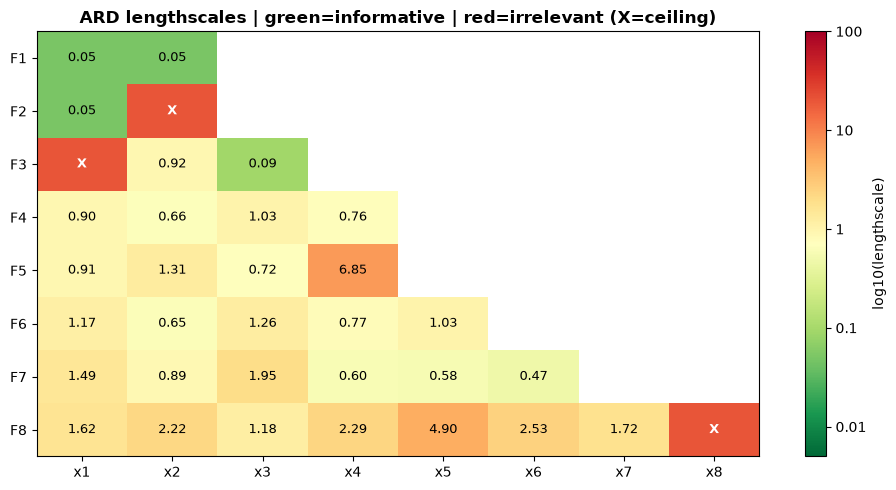

In [7]:
_ = bdiag.plot_lengthscale_heatmap(all_X, gps)

The SHAP beeswarm plots are included to show the direction of each dimension's effect in addition to its magnitude, since the bar charts and heatmaps elsewhere report magnitude only. This makes it possible to determine whether a higher value of x_i increases or decreases y, and whether an apparently important dimension reflects a broad, consistent effect or is instead driven by one or two individual points, which is a genuine risk given limited sample sizes.

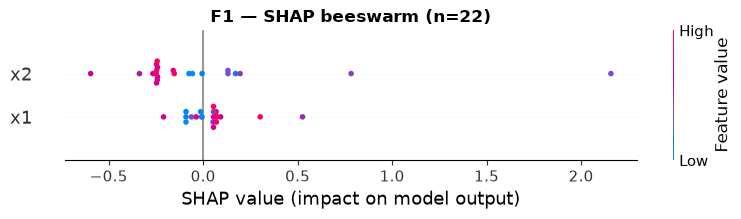

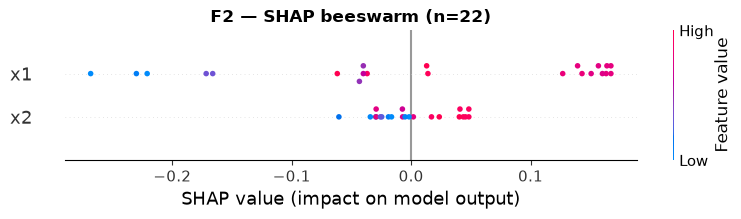

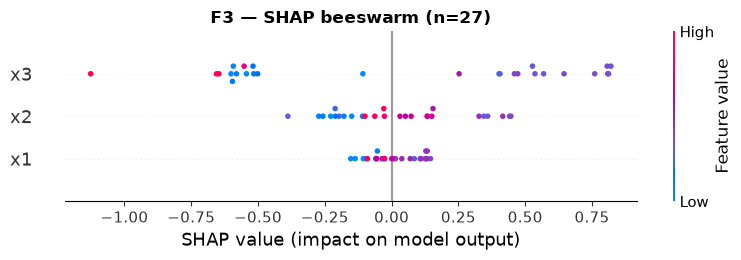

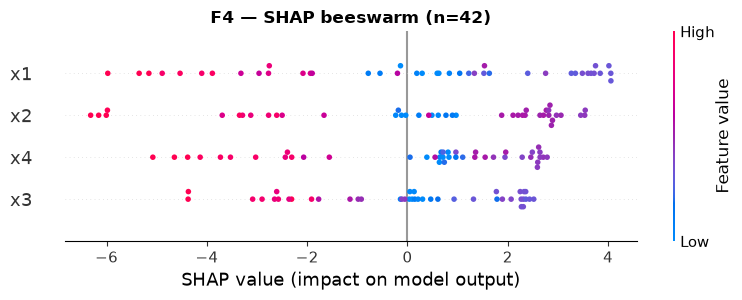

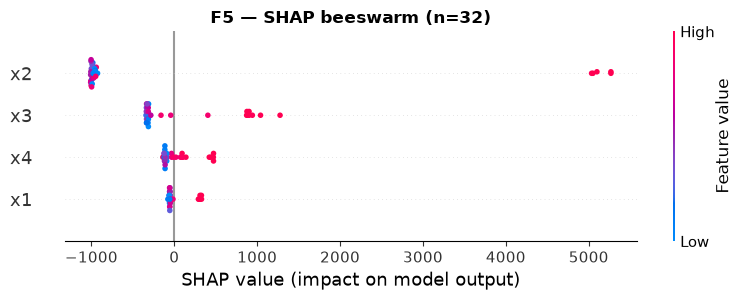

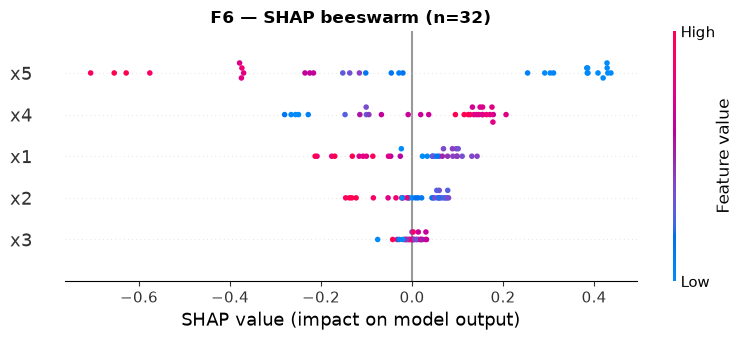

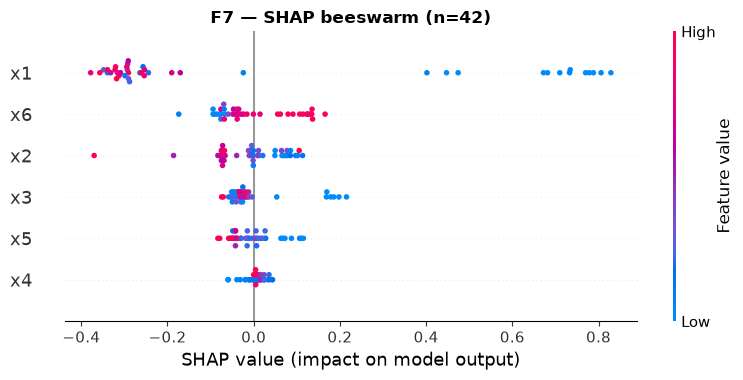

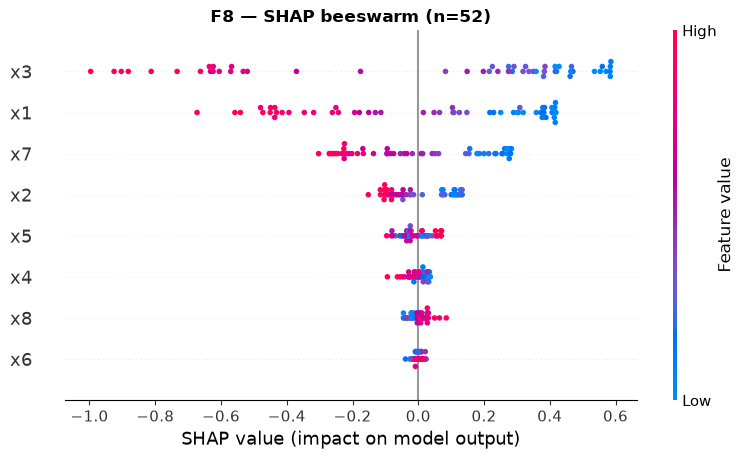

In [8]:
bdiag.plot_all_shap_beeswarm(all_X, all_y)

F7's two frozen dimensions, x1 and x3, both show disagreement between the two metric families. The RF-family metrics are close to 1.0 while the GP-family metrics are considerably lower. This is precisely the type of disagreement between families that the heatmap and scatter panels below are designed identify.

That said, while x3 was frozen due to it being deemed irrelevant by the consensus panel, the incumbent currently has x1 at 0 and based on the GP slice visualisations and the output steeply decreases at higher values of x1. Hennce x1 was also frozen at 0. 

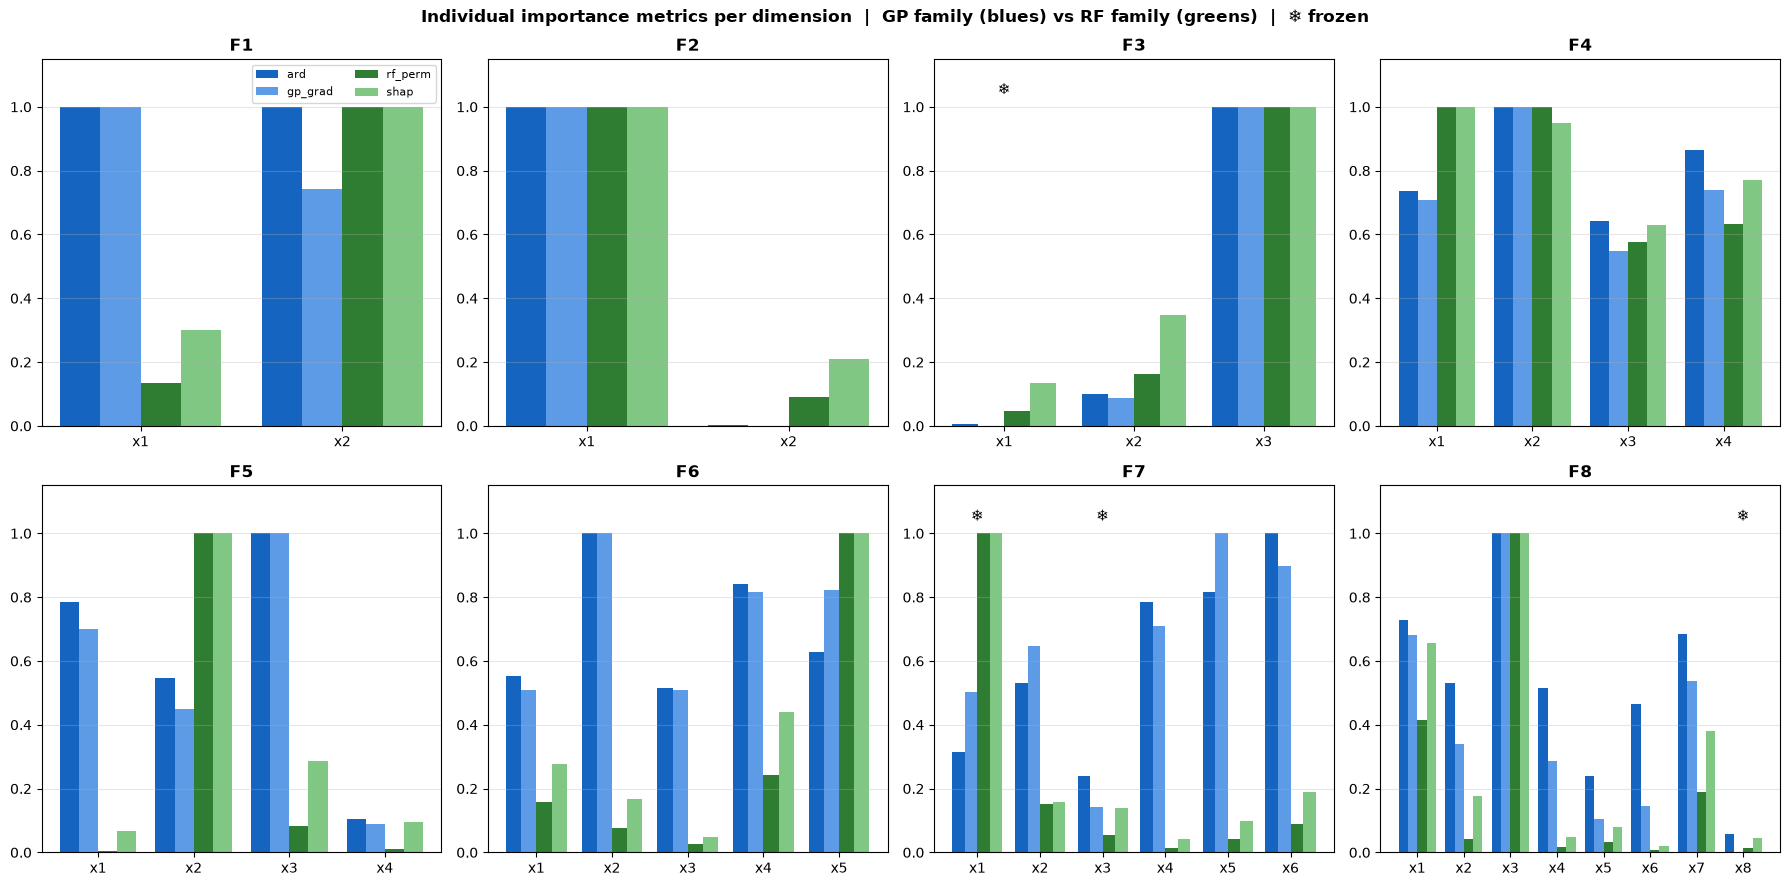

In [9]:
bdiag.plot_importance_bars(diagnostics)

The plot below shows the normalised dimension importance between the two families. The points shown in red, where |GP-RF| exceeds 0.5, identify dimensions for which no single importance signal should be trusted in isolation. F1's x1, F5's x1, x2, and x3, and F7's x1 and x6 all fall into this category. For these dimensions, the GP-family and RF-family metrics genuinely disagree on whether the dimension matters, not merely on the extent to which it does.

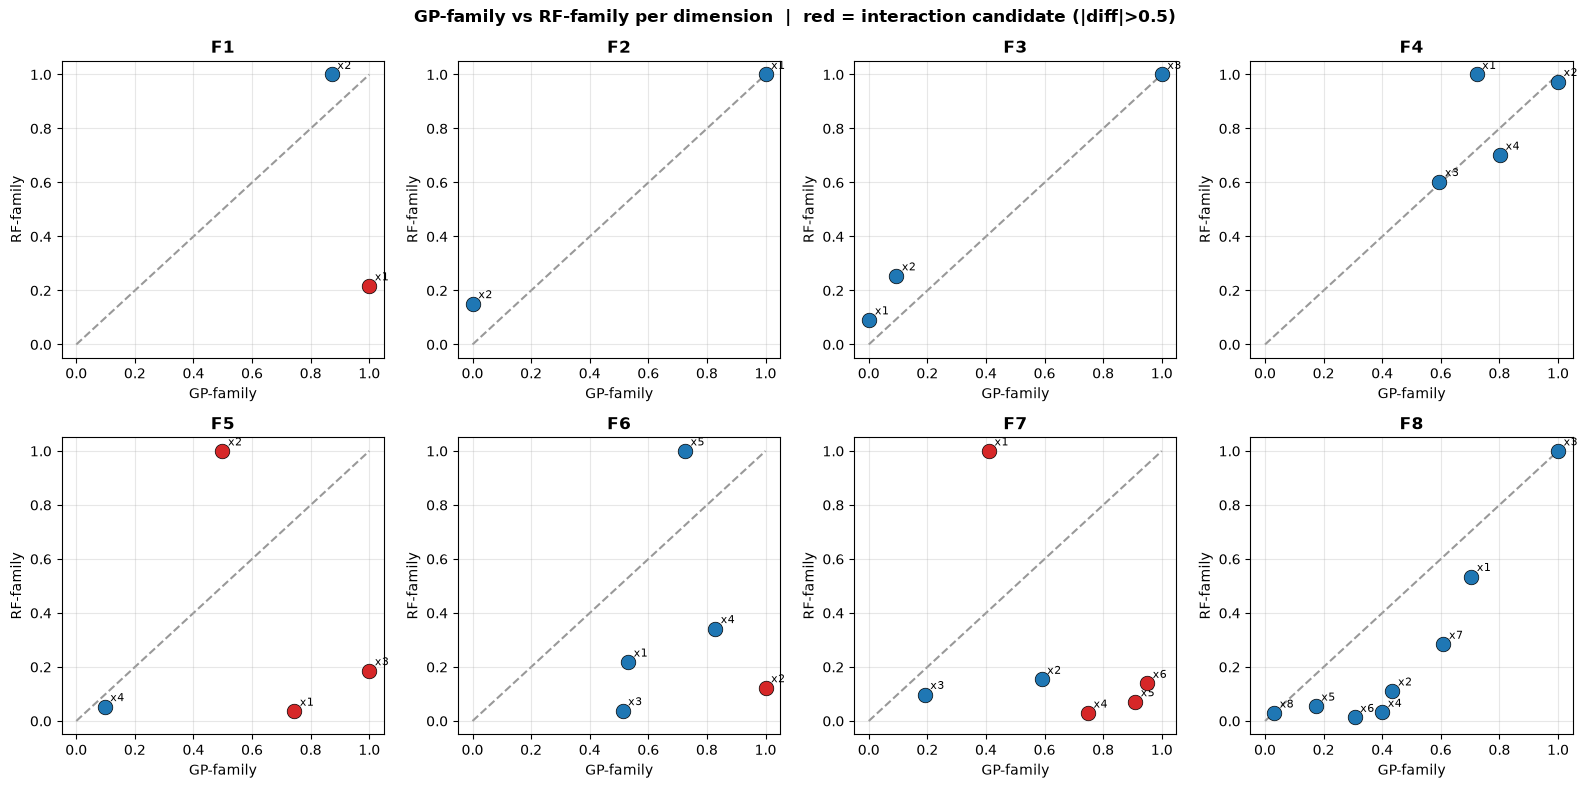

In [10]:
bdiag.plot_importance_scatter(diagnostics)

F5 stands out on the disagreement panel, with three of its four dimensions (x1, x2, and x3) showing |GP-RF| values above 0.5, showing the conflict between the two families. This is consistent with F5 being a vertex optimum, since a stationary GP kernel and a tree ensemble identify very different structure in a function whose true optimum depends on selecting the correct corner of the domain rather than on smooth variation.

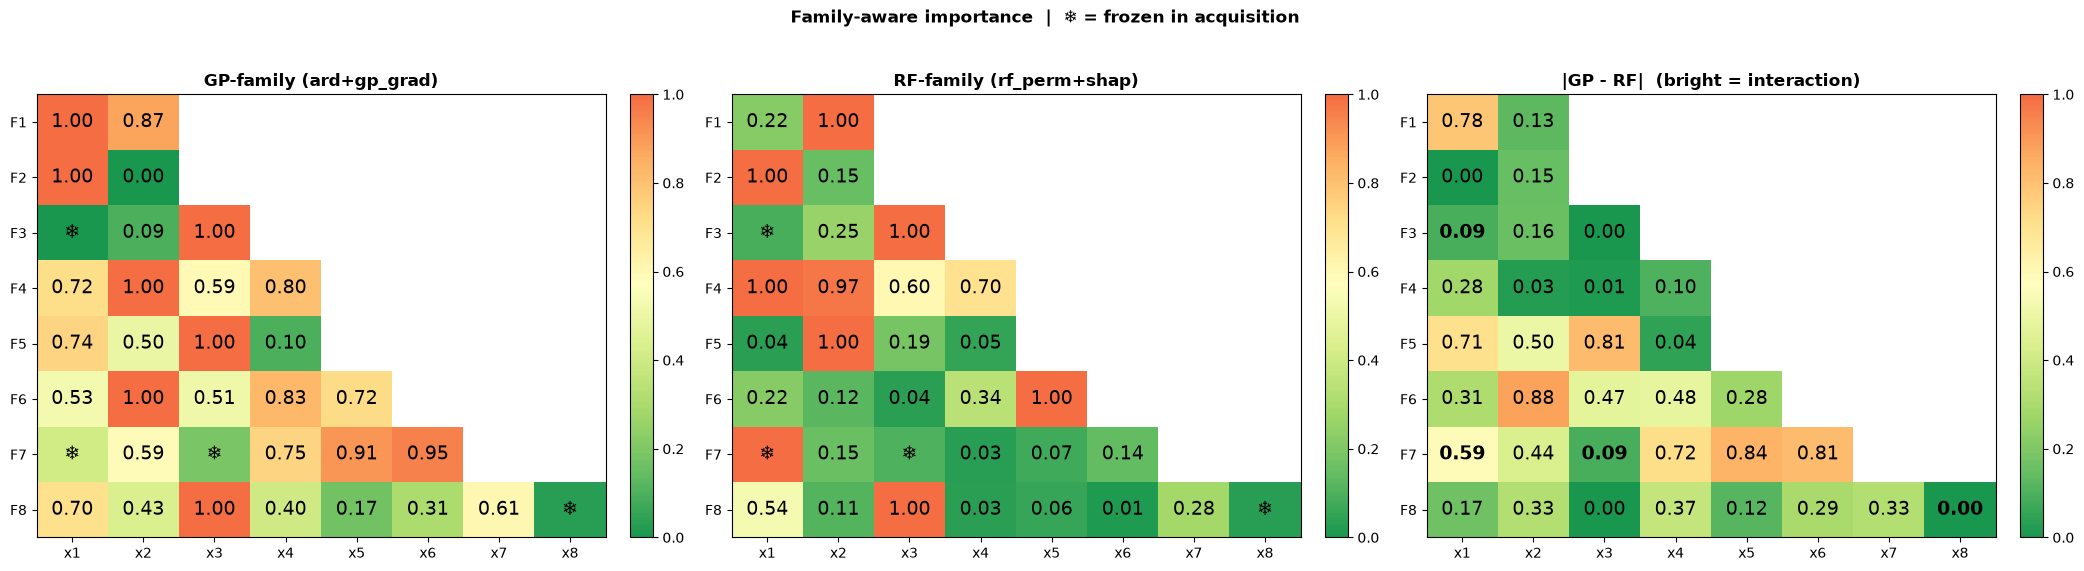

In [11]:
bdiag.plot_importance_heatmaps(diagnostics)

## 3. R² narrative

The tabulation below illustrates different diagnostic metrics. The before and after columns correspond to two distinct LOO-CV procedures, `loo_cv_leaky_warpedscale` and `loo_cv_leakproof_rawscale`. In the former, the warp is fitted once on the full dataset, so each fold's target transform is partly informed by the point it later holds out. And since duplicate queries were made for F2 and F5 to confirm if they were stochastic, these rows are treated as independent, allowing a duplicate's counterpart to remain in training while its pair is withheld. Moreover, R² is computed on the warped scale. In the latter, the warp is refitted within each fold using only that fold's training data, near-duplicate rows are withheld together, and predictions are inverted to the raw scale before R² is computed. As these three differences act cumulatively, the two columns should be read as related but non-equivalent quantities, highlighting the importance of appropriate validation workflow when warping is used.

F3 shows the largest decrease between these metrics, with leakprone R² of 0.732 vs the leakfree R2 of 0.336. This is expected for a Yeo-Johnson-warped function, since `loo_cv_leaky_warpedscale` is computed entirely in warped space and is therefore never exposed to the tail-amplification effect that the raw-scale `loo_cv_leakproof_rawscale` metric captures. 

Two diagnostic flags accompany each function's LOO R²: `single_fold_driven`, which indicates a low R² caused by a single difficult point rather than a broadly unreliable fit, and `clip_dominated`, which indicates a low R² caused by several folds hitting the Yeo-Johnson transform's boundary rather than genuine prediction error. No function is currently flagged under either condition, so any low R² observed this week reflects a genuine limitation of the model rather than an artefact of the evaluation procedure.

In [12]:
bdiag.print_r2_story(df_cmp)

          d warp   nu  loo_r2_leaky_warpedscale  loo_r2_leakproof_rawscale  delta  loo_r2_trim1  loo_rho  amp_at_worst_fold n_clipped  n_dup_groups route_before route_after strategy_used  single_fold_driven  clip_dominated
function                                                                                                                                                                                                                      
1         2  yeo  1.5                    -0.553                     -0.047  0.505       -38.143    0.085               0.00      0/22             0        turbo       turbo      turbo_mb               False           False
2         2  log  2.5                     0.524                      0.559  0.036         0.655    0.737               1.63      0/22             1       global      global        global               False           False
3         3  yeo  1.5                     0.732                      0.336 -0.396         0.740    0.876    

F1's scatter plot is the visual counterpart of its R² value of -0.047: all but one point lie close to y = 0, and the model predicts a near-zero value for the needle point as well, since it has no basis for inferring a spike from data that otherwise appears uniformly flat. F5 shows the opposite pattern: the two points near the vertex value of 8000 or higher are predicted almost exactly, which raises the overall R² despite comparatively noisier predictions in the 0 to 2000 range.

F4 and F8 show the most trustworthy fit among all the functions, and this is reflected in the near-monotonic improvement both saw over the course of the weekly rounds. 

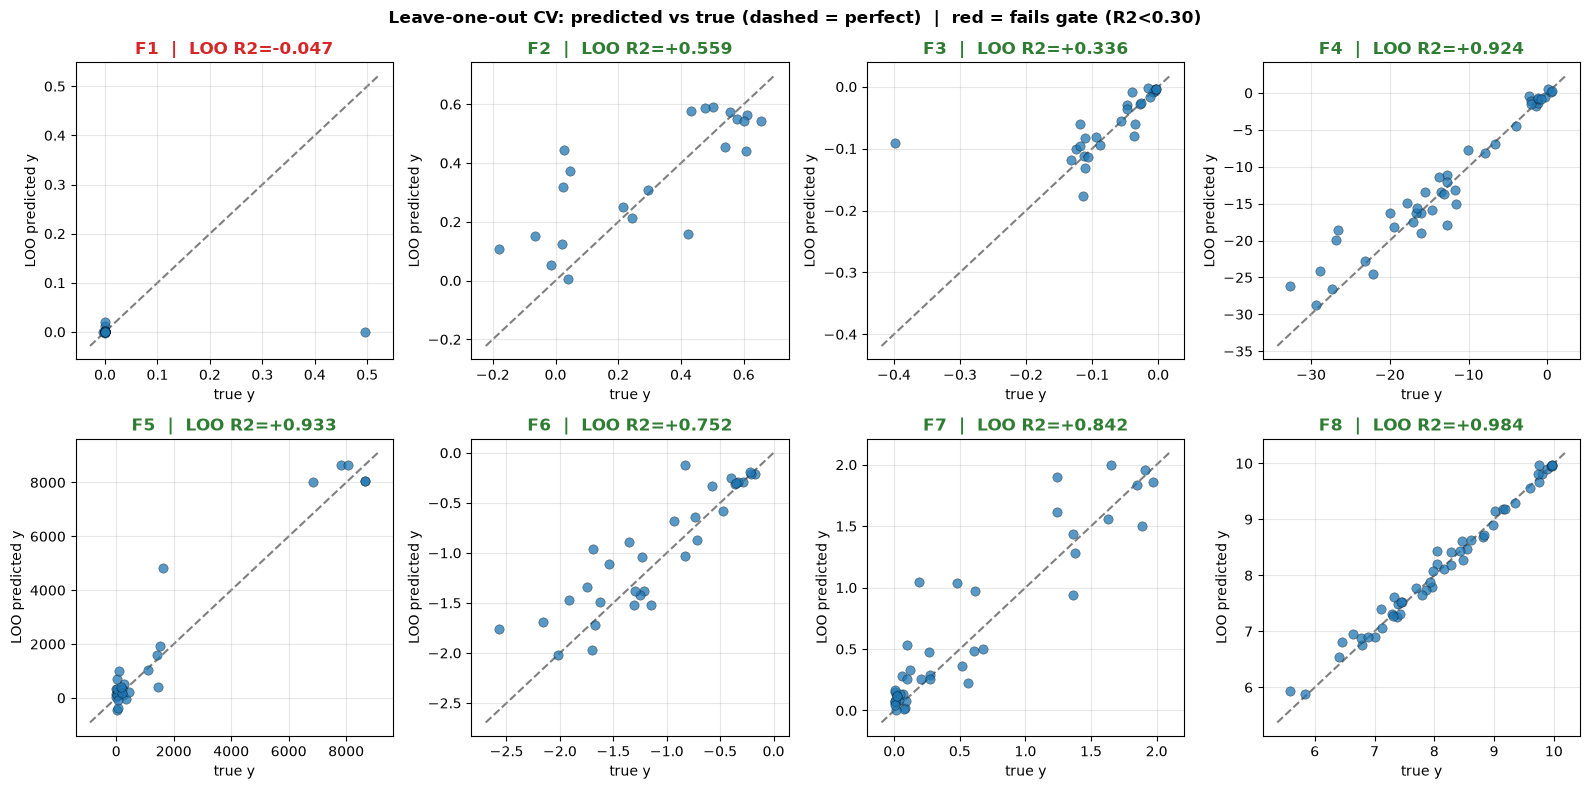

In [13]:
bdiag.plot_loo_diagnostic(diagnostics)

## 4. Acquisition comparison

The illustration below shows what EI / UCB / PI (or TuRBO / corners / needle's own candidate) each predict, and which one actually got selected (bold outline) for this week's submission.

F5's panel differs from the others by design: the `forced` bar shows the current best value, `y_max_so_far`, as a flat outline rather than the result of a genuine comparison between EI, UCB, and PI, because F5's suggestion originates from the manual override as a result of the `corners` strategy which explores the vertices in the descending order of maximum distance from the available data rather than from automatic acquisition selection.

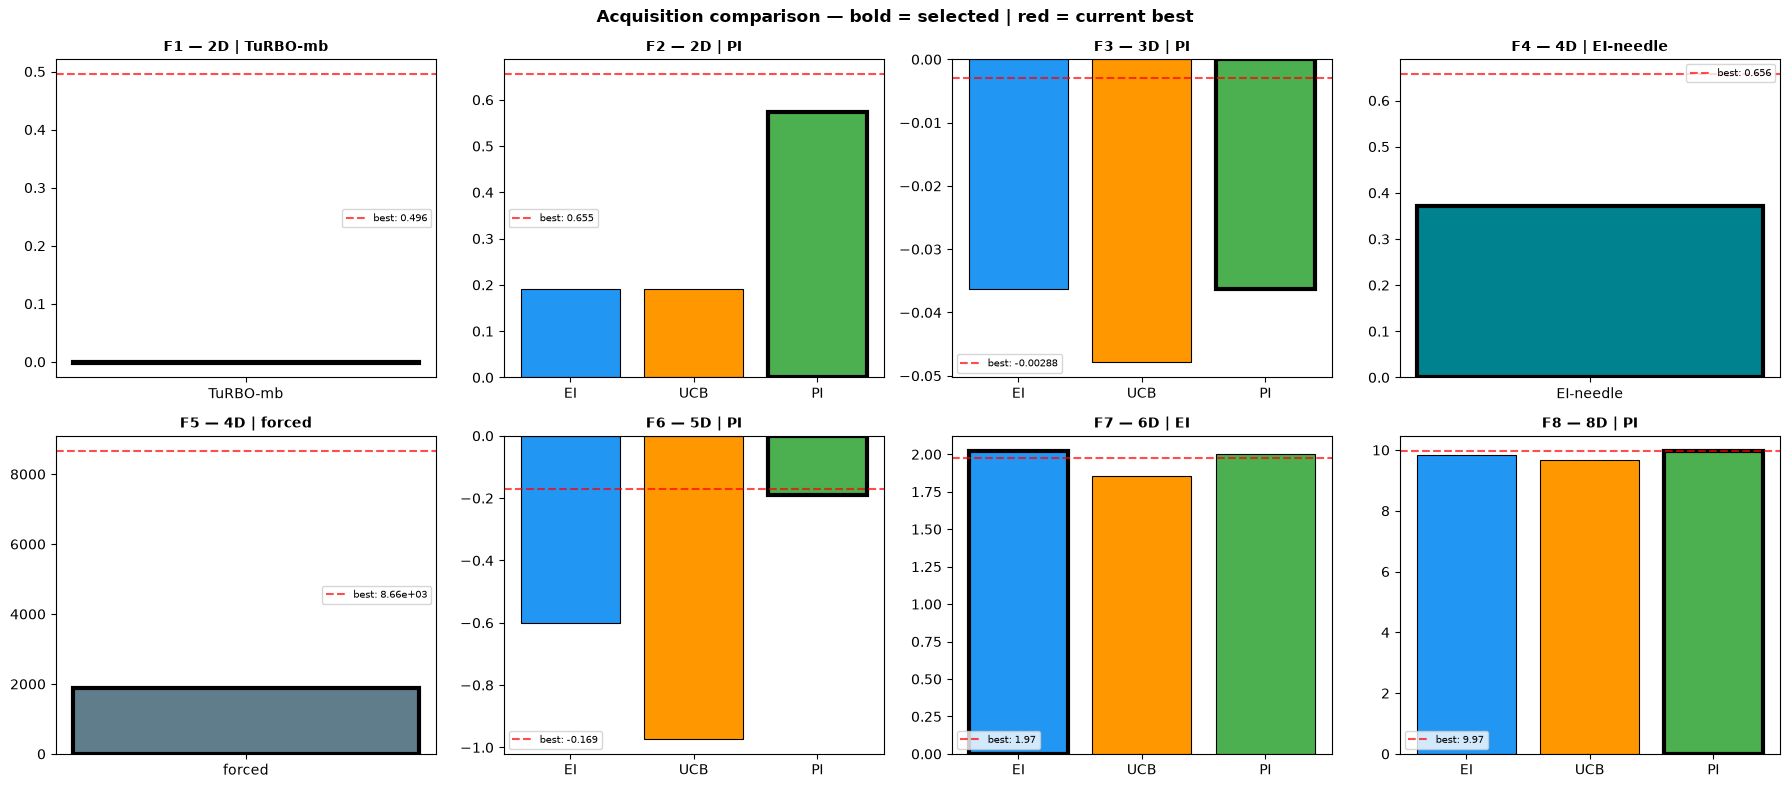

In [14]:
bdiag.plot_acquisition_comparison(df_all, df_best)

## 5. Interpretability

### 5.1 Marginal plots (x_i vs y)

The marginal plots provide a visual illustration of how each function varies linearly with every dimension, when all the other dimensions are fixed. While this is substantial simplification, a higher slope for the trendline along with higher correlation coefficient can be considered as an indication of that dimension's influence on the function's output

F1's marginal plots make the needle-like structure clear: the correlation coefficients are -0.04 and -0.12 for x1 and x2 respectively, indicating essentially no linear relationship in either raw dimension. This is consistent with a single spike located on an otherwise flat surface.

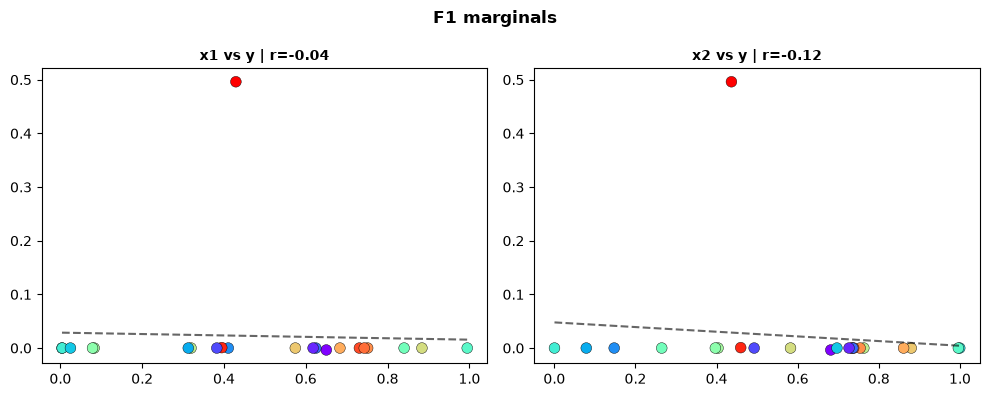

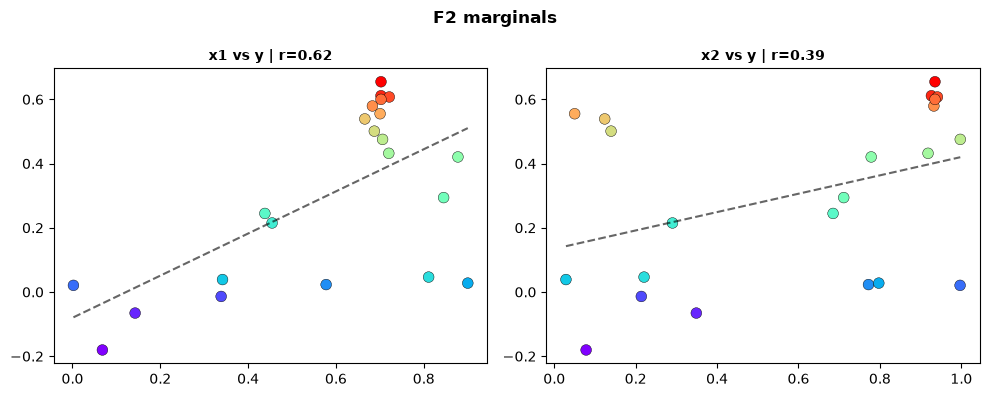

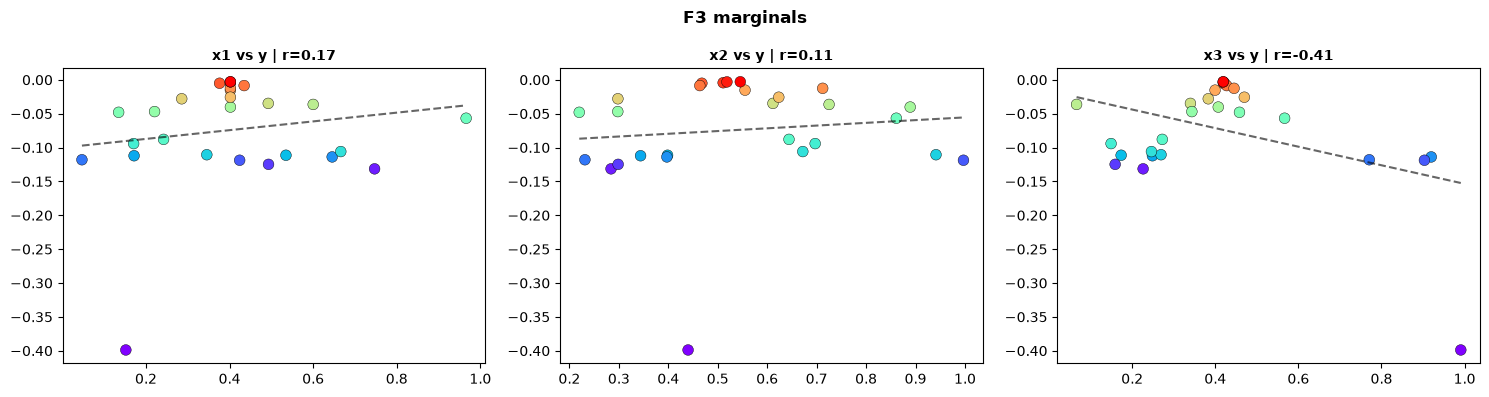

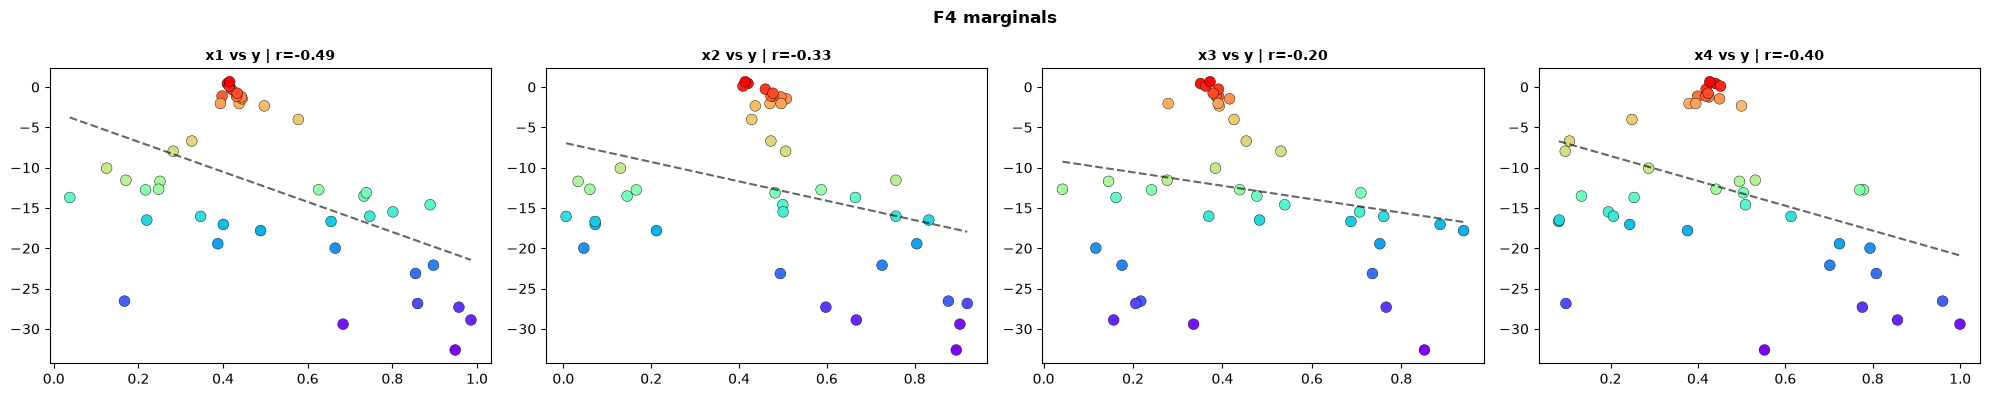

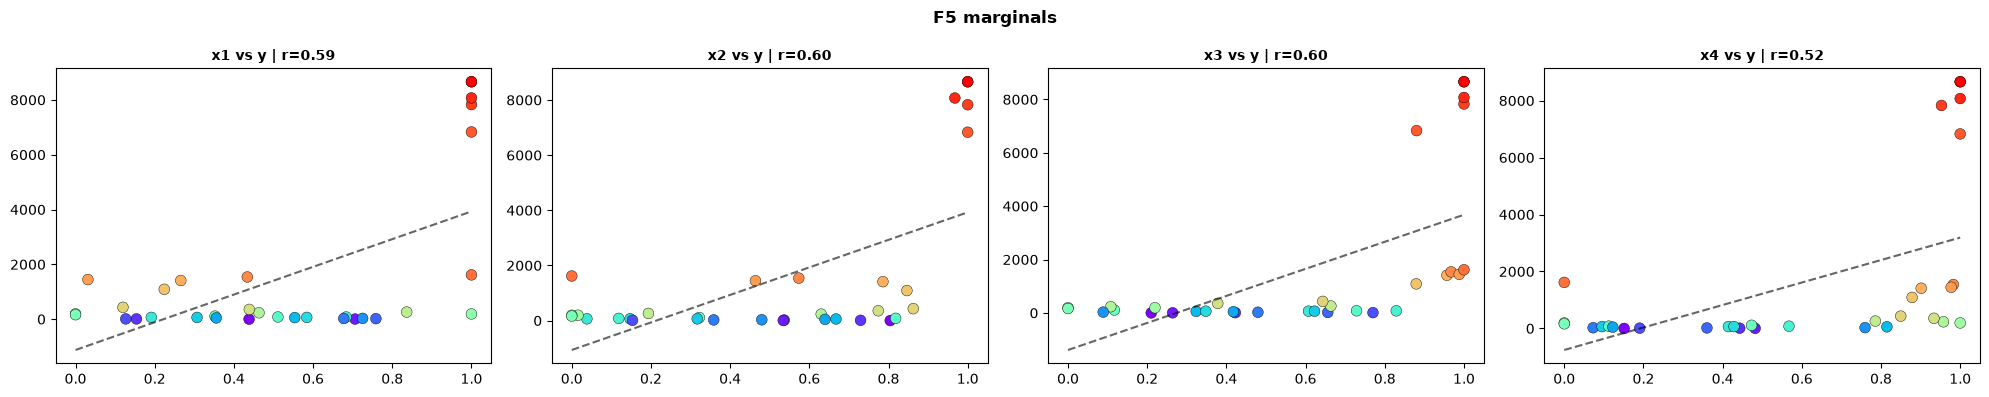

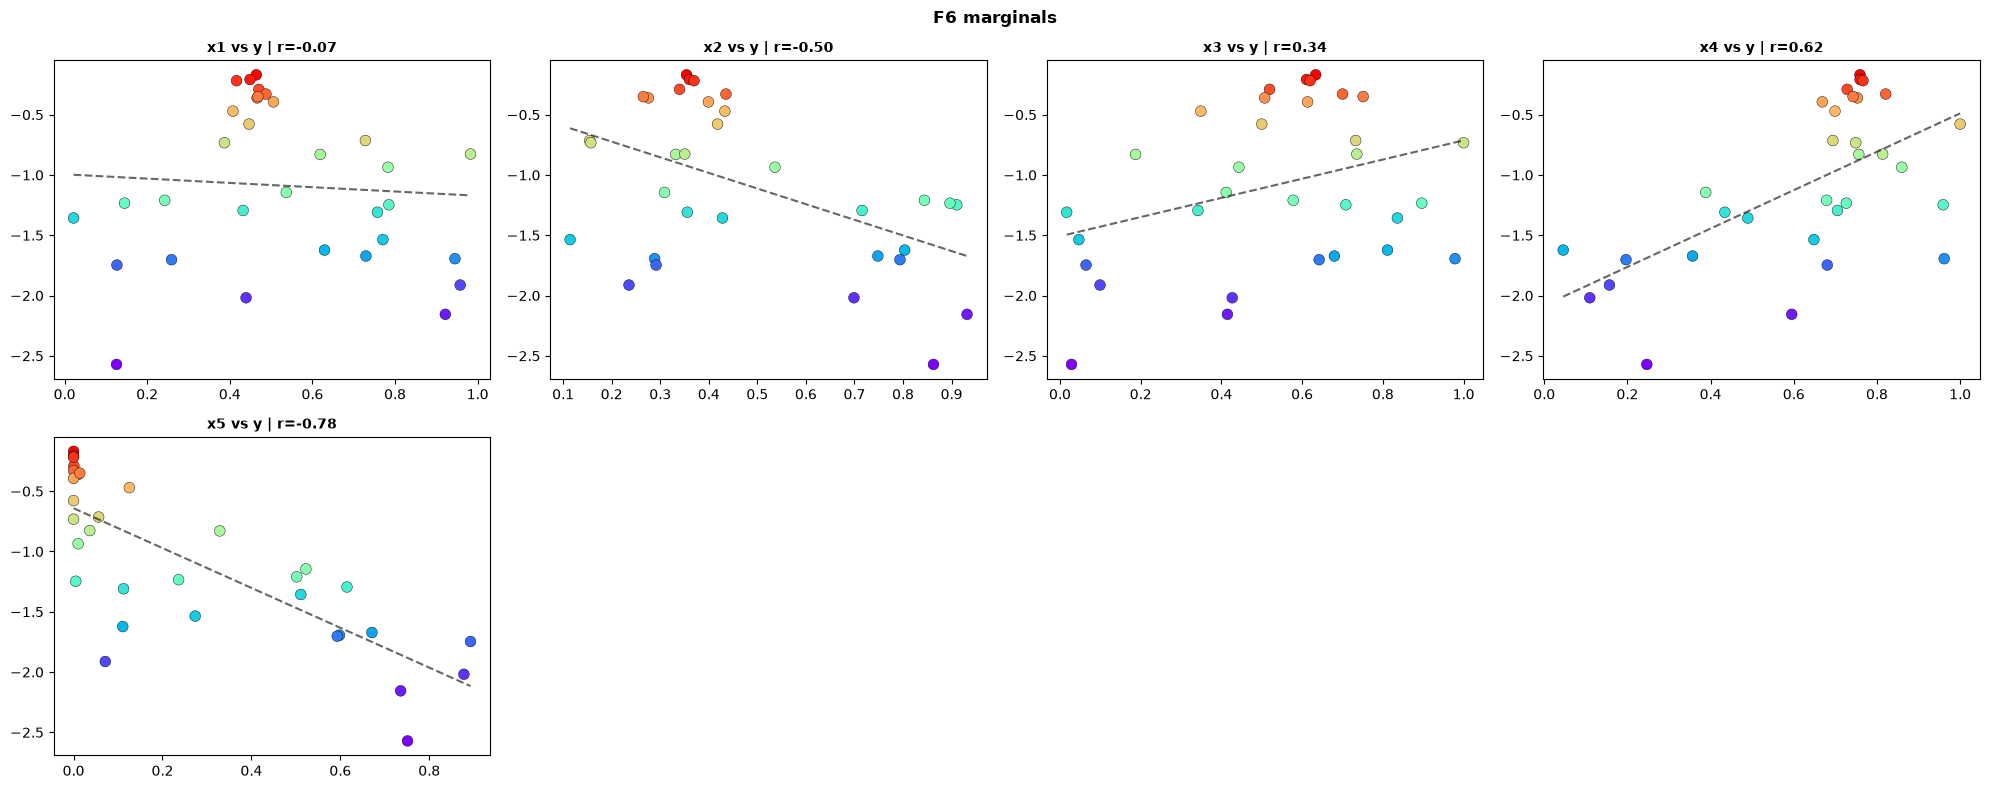

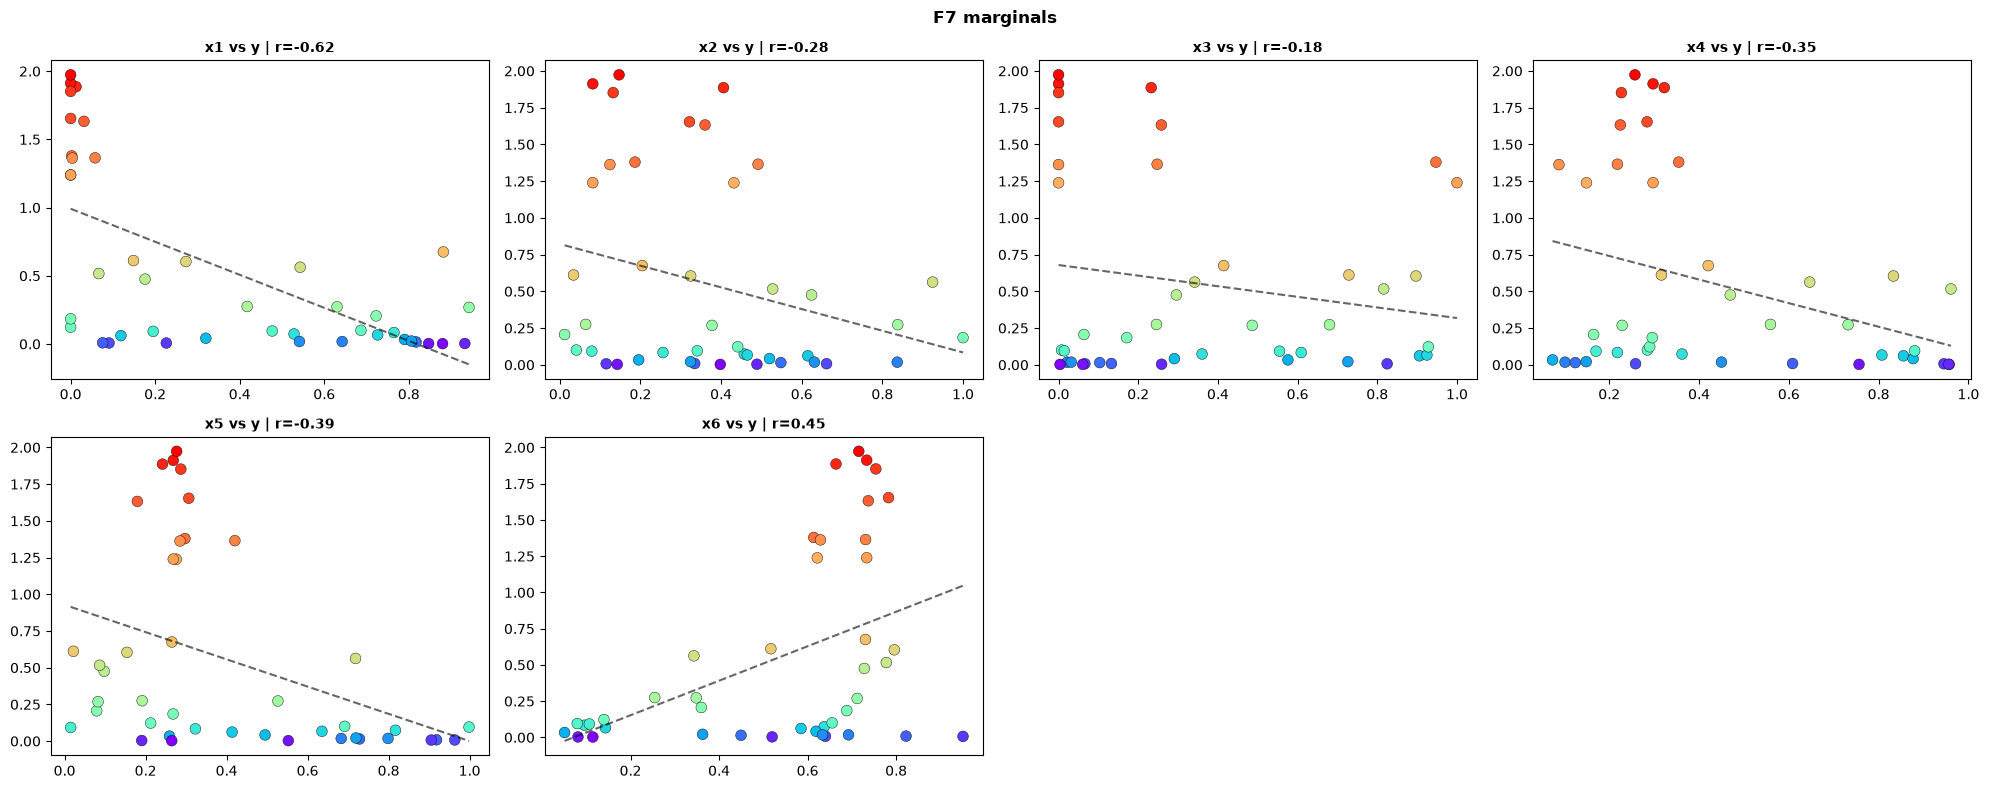

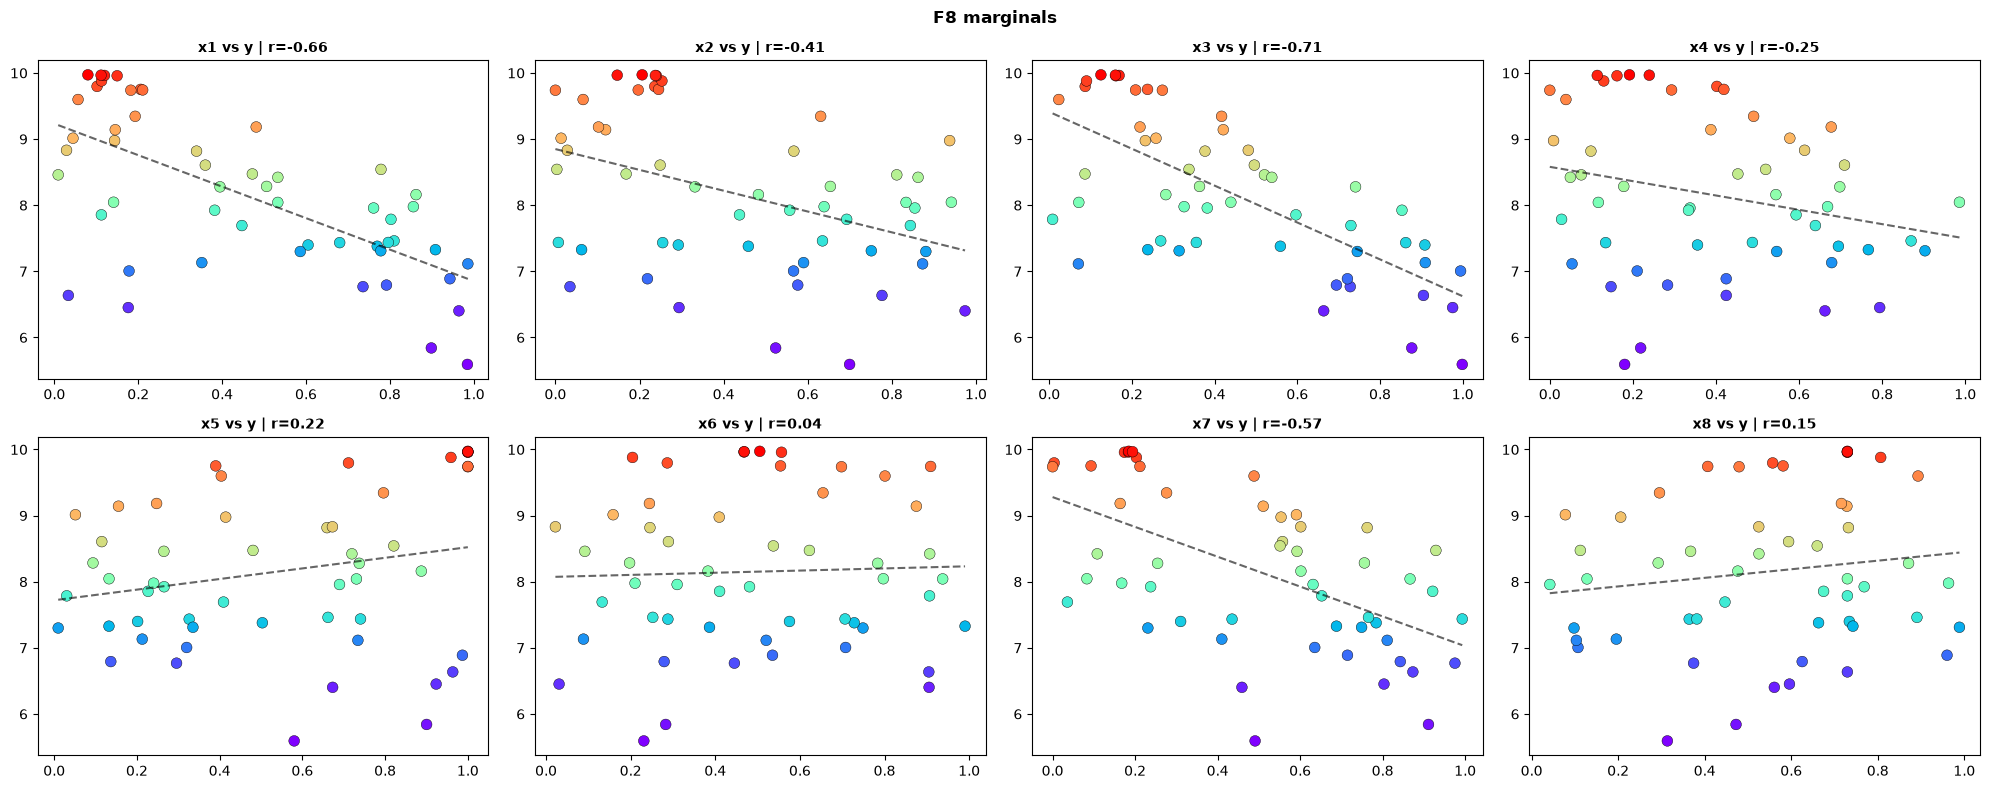

In [15]:
bdiag.plot_all_marginals(all_X, all_y)

### 5.2 GP surface slices (3D, top-2 dimensions per function)

The 3D slice for the GP is rendered below considering the top two important dimensions, while every other dimension held fixed at the incumbent. The slices clearly show how much of the observed scatter the surrogate is (and isn't) explaining. Also, F1's needle-like spike on the otherwise flat landscape is consistent with its negative LOO R².  against F4's clean converged dome.

F1's surface renders as essentially flat across the entire domain, since a stationary kernel cannot represent a single spike. This is constrated with F4's smooth, well-explained surface that peaks at a very narrow region.

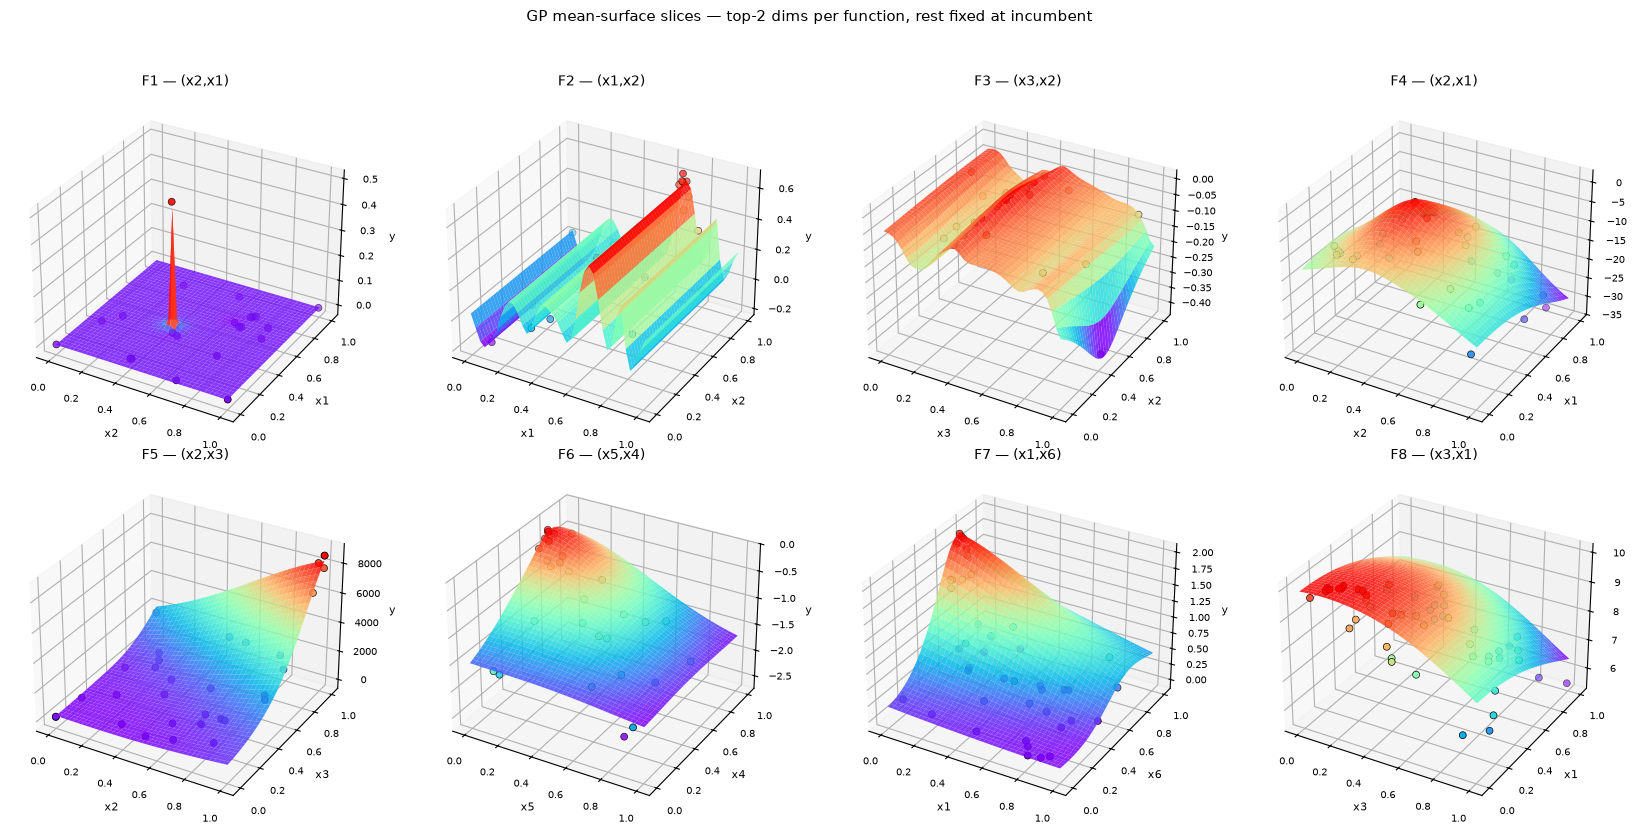

In [16]:
fig = bdiag.plot_gp_surfaces_mpl(all_X, all_y, gps, top_dims)
plt.show()
# Matplotlib-native (see the bottom of bbo_diagnostics.py) -- renders as a plain static image everywhere,
# no Plotly/Kaleido dependency. Same computation as before: every non-top-2 dimension is
# fixed at each function's true incumbent (best observed point).

This is the interactive counterpart to the previous view, applicable to functions with three or more dimensions. The same top-two-dimension surface is shown, but the third most important dimension is controlled by a slider rather than held fixed, allowing the surface's deformation to be observed directly rather than inferred from a single static slice. The slider position is normalised to the range [0,1] to one and maps independently onto each function's own third dimension. For F3, since the third dimension was frozen as indicated by the consensus panel, the GP surface doesn't change with the slider. On the other hand for F6, F7, and F8, the third dimension carries genuine signal.

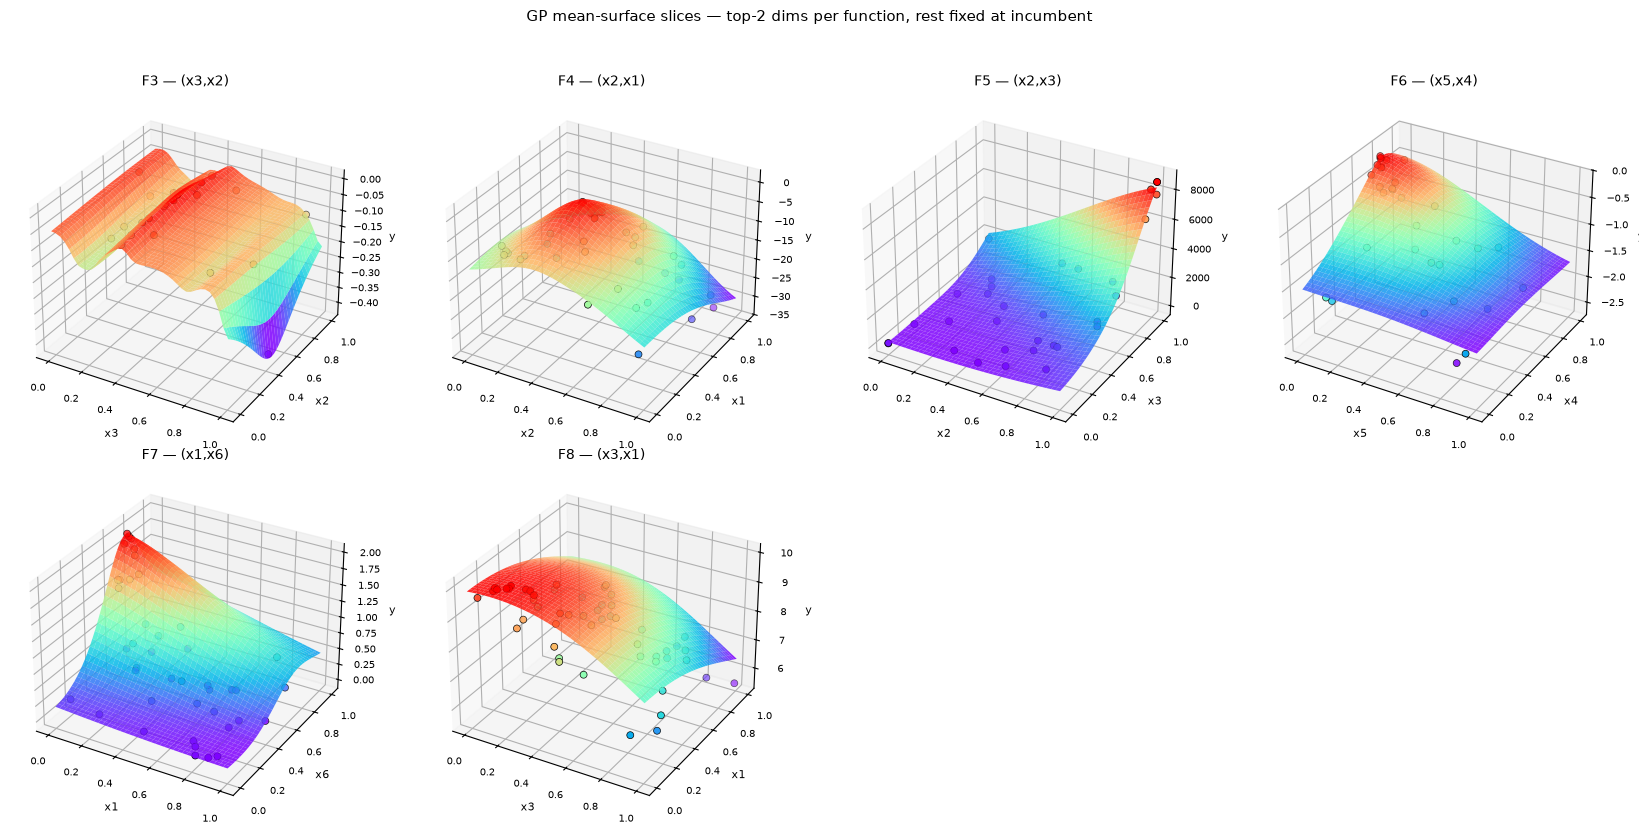

In [17]:
# The interactive slider is replaced with a single static view. This is not an approximation:
# plot_gp_surfaces_mpl already fixes EVERY non-top-2 dimension (including this one) at the true
# incumbent xb = X[argmax(Yraw)] -- i.e. this IS the slider's fully-resolved 'at incumbent' position.
fig = bdiag.plot_gp_surfaces_mpl(all_X, all_y, gps, top_dims, fns=(3, 4, 5, 6, 7, 8))
plt.show()

### 5.3 Trust region plots (functions currently on turbo / turbo_mb)

Each horizontal bar spans the current trust-region bounds (0 to 1) for one input dimension, with grey markers showing every previously observed point along that dimension and a red marker indicating the incumbent, xb. The bar's width is set directly by the trust-region length, and its position is re-centred on xb whenever the incumbent changes, so an unusually narrow or off-centre bar is not a plotting artefact but a direct reflection of the search's current state: a small length indicates repeated recent failures to improve on the incumbent, rather than a fault in the search procedure itself.

Comparing the bar's extent against the spread of the grey observed points also indicates how much of the previously explored input space the current trust region still covers. A trust region substantially narrower than the historical spread of observations suggests the search has contracted toward a specific sub-region following sustained local improvement, while a region comparable in width to the full observed range suggests the search remains in an earlier, less contracted phase.

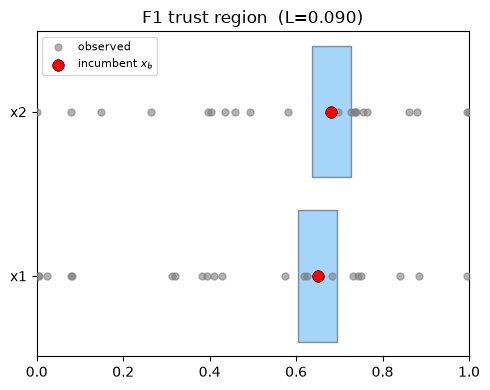

In [18]:
bdiag.plot_trust_regions(all_X, df_best)

### 5.4 Differential evolution tracer

Every function using the `global` strategy obtains its proposed point from a differential evolution run, which is iterative process consisting of a population evolving across generations. The shaded area highlights the range of EI score for points that range between 5th and 95th percentile compared to the point with highest score. Of the five functions using the `global` strategy, F2 and F3 converge within 30 iterations, while F8 continues to improve until the 80th generation. This indicates that DE was able to successfully 

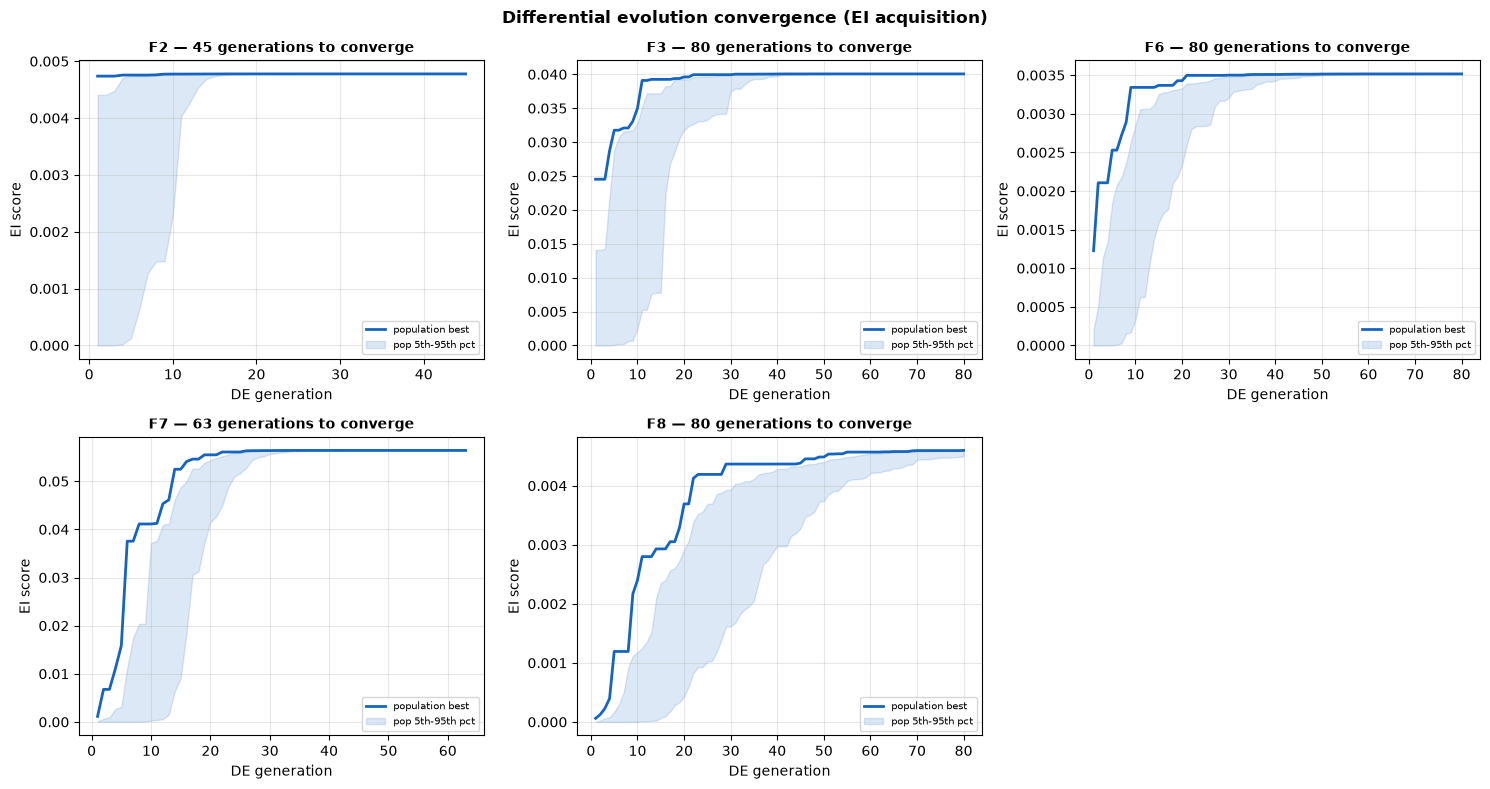

In [19]:
_ = bdiag.plot_de_convergence(all_X, all_y, gps, diagnostics)

This visualisation below shows differential evolution operating directly upon the surface it is optimising. The surface displayed represents the acquisition score, expected improvement in this instance, rather than the raw predicted target value, and goal is to maximise this score. The surface is computed over each function's two most important active dimensions, and the live population is overlaid at each individual's true acquisition score. 

The gap between the population and the surface should be interpreted carefully. F2 and F3 are the only functions with exactly two active dimensions, meaning their populations have no additional dimension in which to move; their points therefore sit essentially on the surface. On the other hand, F6, F7, and F8 have more active dimensions than this two-dimensional slice can represent, so their populations legitimately float above or below the surface at their projected position. This reflects movement occurring in dimensions the view cannot display, rather than an inconsistency in the visualisation.

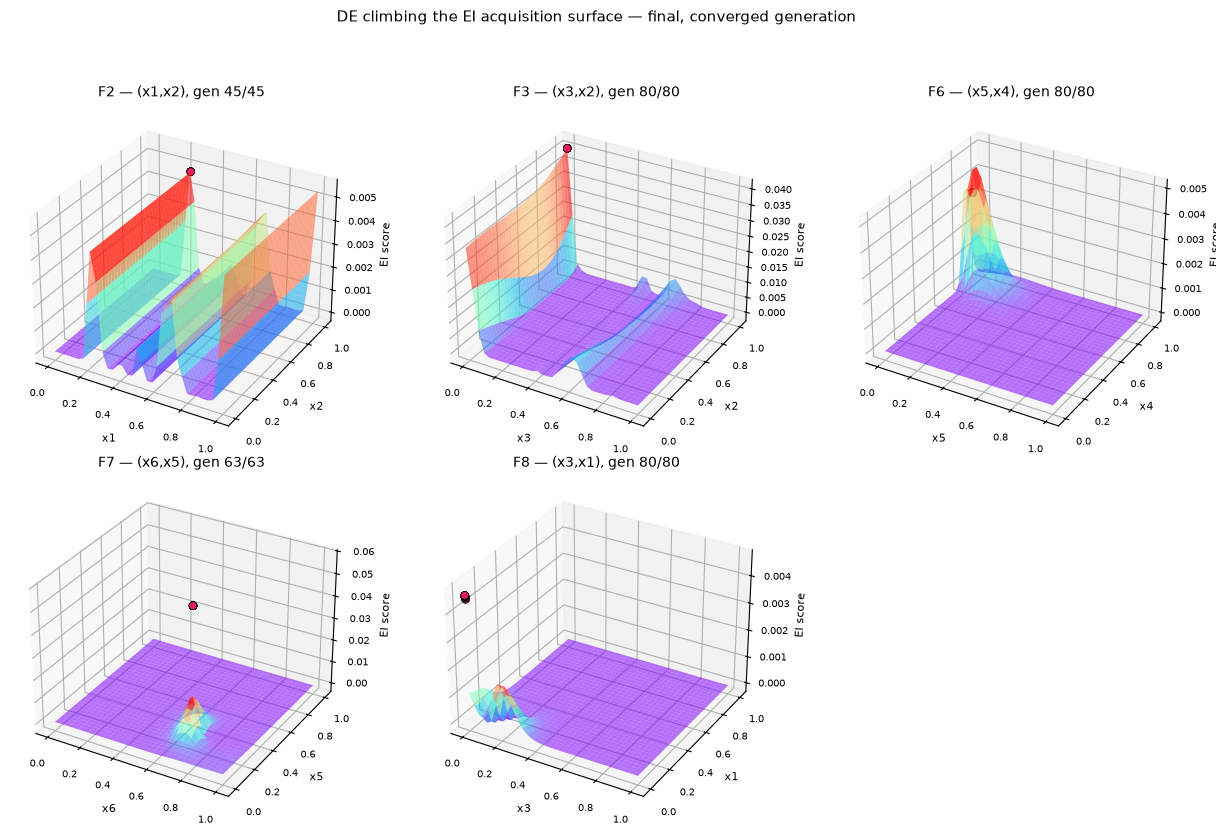

In [20]:
fig = bdiag.plot_de_climbing_mpl(all_X, all_y, gps, diagnostics, acquisition='EI')
plt.show()
# Matplotlib-native, shown at the final (fully-converged) generation. For the full animated
# climb across every generation, see the GIF-export cell below.

In [21]:
bdiag.save_de_climbing_gif_mpl(all_X, all_y, gps, diagnostics, acquisition='EI',
                                    out_path='de_climbing.gif', stride=2, fps=8)

Saved: de_climbing.gif


### 5.5 Cluster plots (k-means on X, unsupervised)

This visualisation applies k-means clustering to the input coordinates, X, independently of the target variable, in order to examine whether the observed data organises into distinct spatial groupings and, if so, how the target value is distributed across them. F1's best point, shown with a black outline, lies within an otherwise unremarkable, low-value cluster, which confirms visually that the needle possesses no local neighbourhood signal: nothing about its surrounding region distinguishes it from typical, unremarkable points. F5's best point, by contrast, is isolated at the extreme corner of its cluster, precisely where a vertex optimum would be expected to lie. For F6, F7 and F8, clusters with distinct mean values represent a clear spatial direction of optimisation.

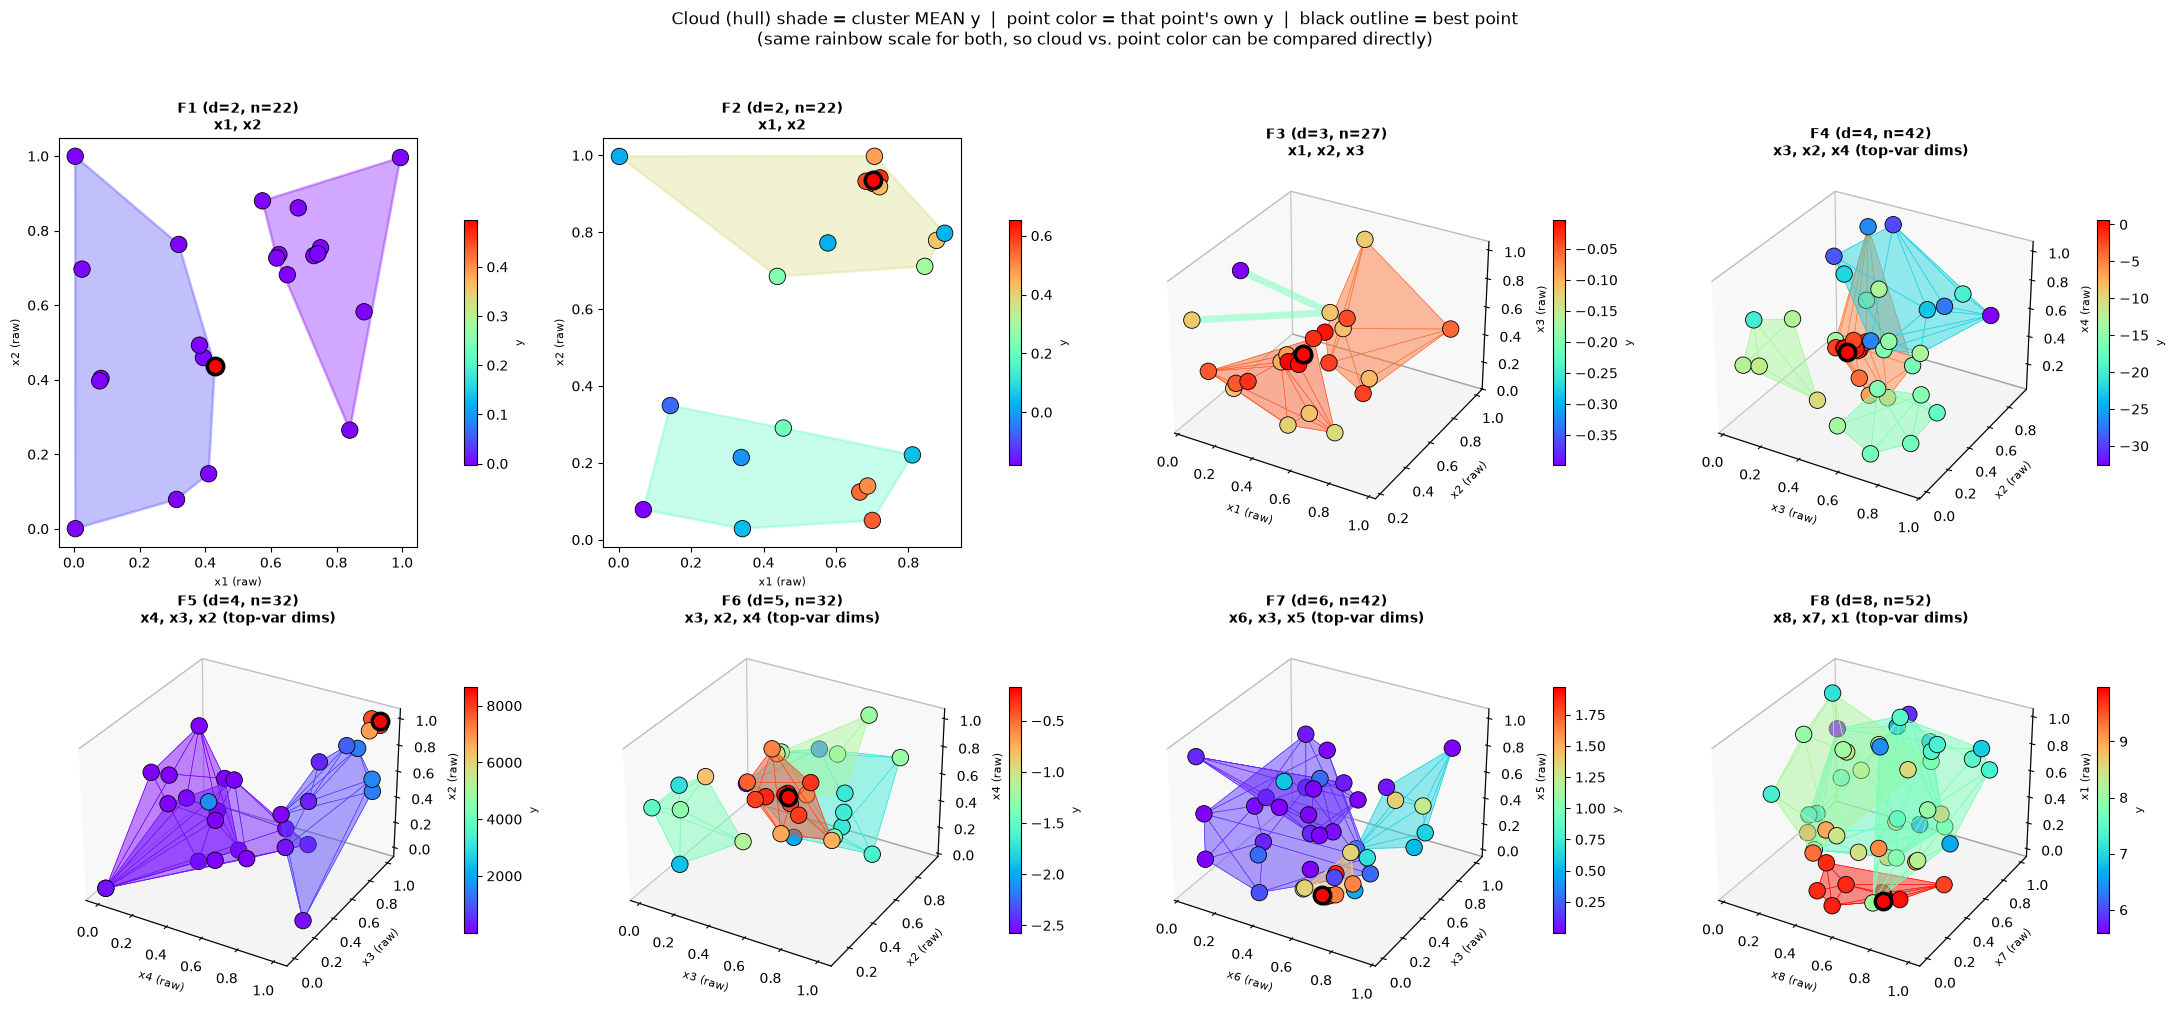

In [22]:
bdiag.plot_clusters(all_X, all_y)

### 5.6 Smart scatter (2D/3D/4D projection onto top consensus dimensions)

This visualisation projects the observed data onto each function's two, three, or four most important dimensions, as determined by the consensus importance score, with colour indicating the target value and the proposed next point marked with a star. F5 provides the clearest illustration in this notebook: the high-value cluster, shown in red and orange above 8000, sits exactly at the (1,1,1,1) corner, while the proposed next point targets a different, previously unvisited corner. This reflects the GP-ranked vertex override, in which the fitted model is used to select among the remaining unvisited vertices, rather than an unranked geometric selection.

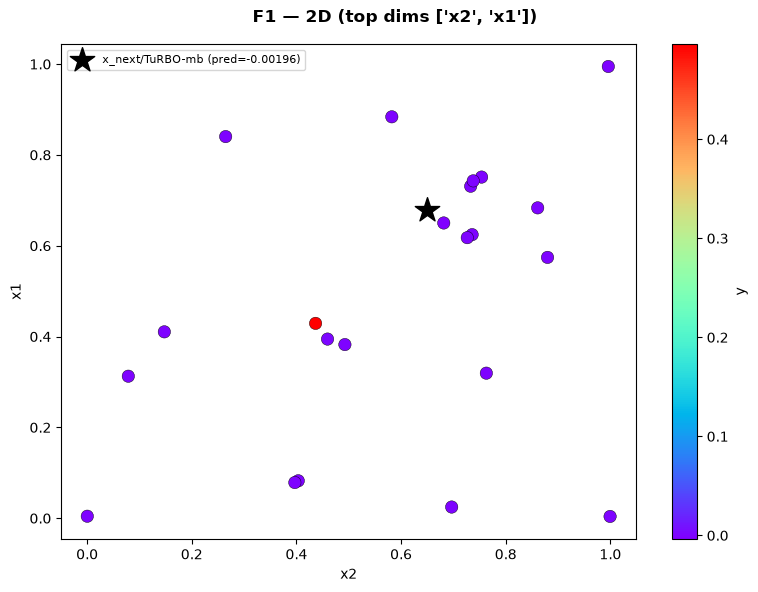

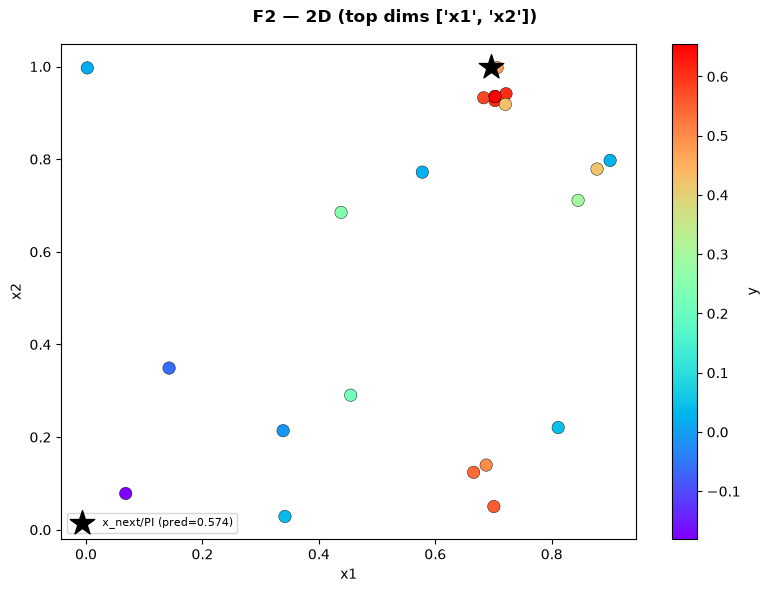

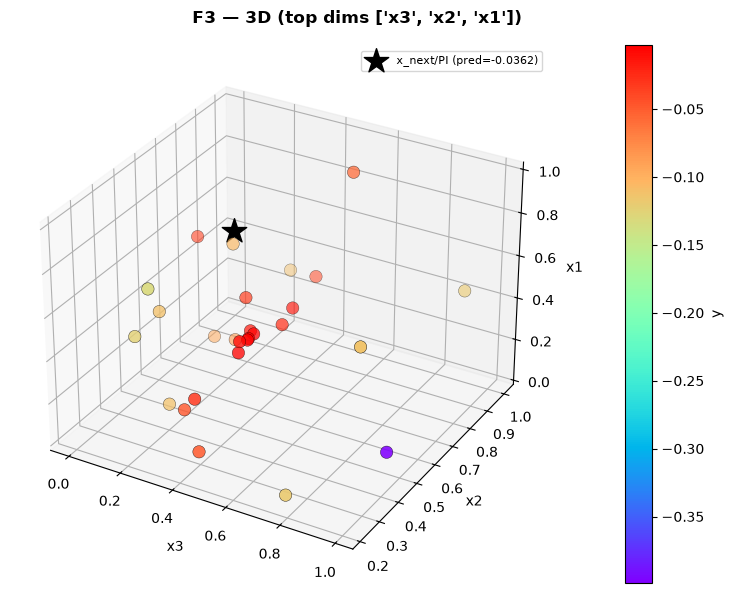

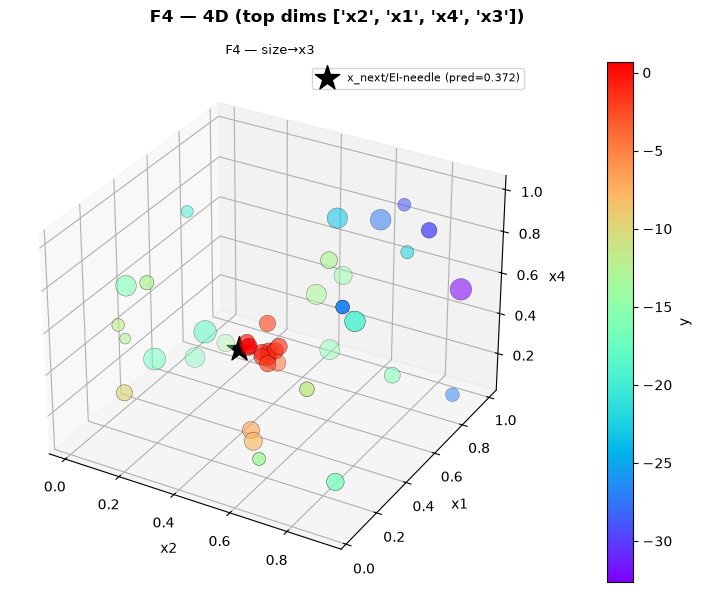

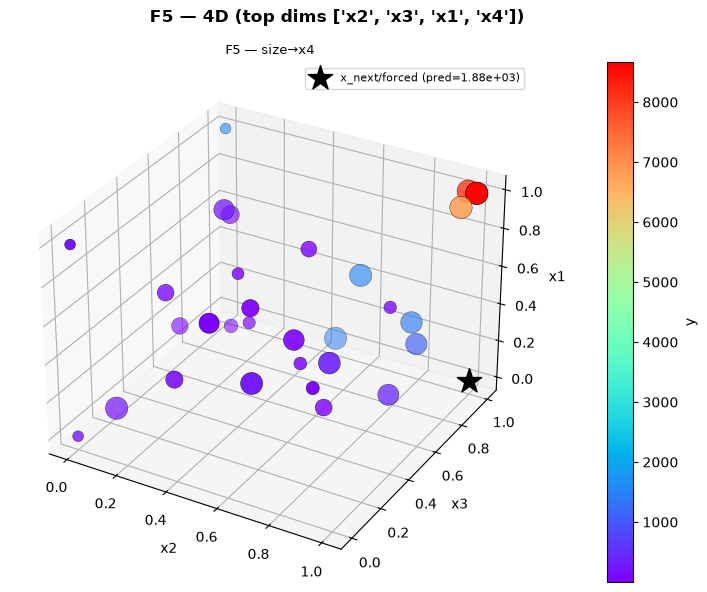

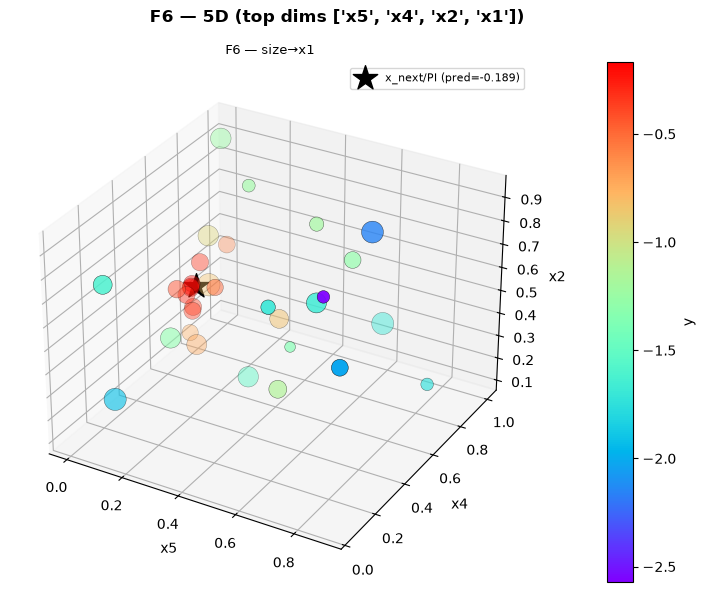

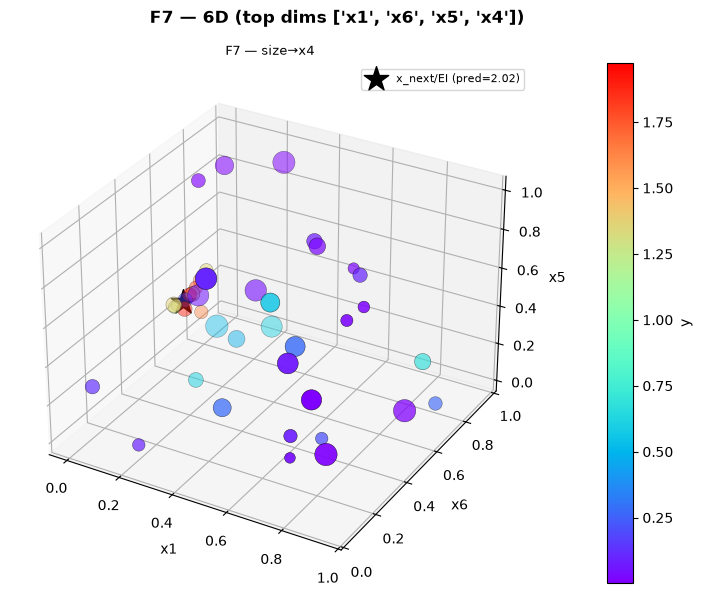

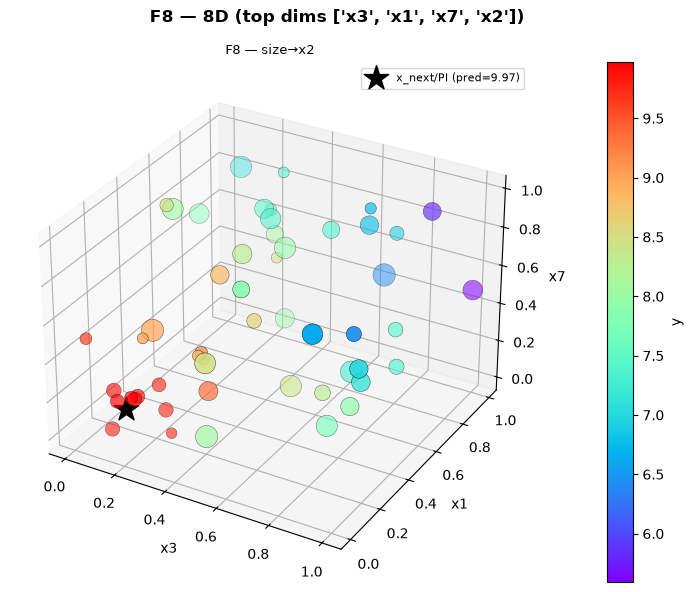

In [23]:
bdiag.plot_all_smart(all_X, all_y, df_best, top_dims)

### 5.7 Parallel coordinates plots

This visualisation displays each observed point as a line traversing every input dimension, with colour indicating the corresponding target value and the proposed next point overlaid in bold. F3's plot excludes its lowest-value outlier, because a single very low-y observation would otherwise dominate the colour scale and obscure the variation among the remaining, more typical points.

Also apparent are F4's needle comprised of region around 0.4 for all the dimensions, F5 showing its vertex-dominant nature and F1 showing a single large result at the current incumbent.

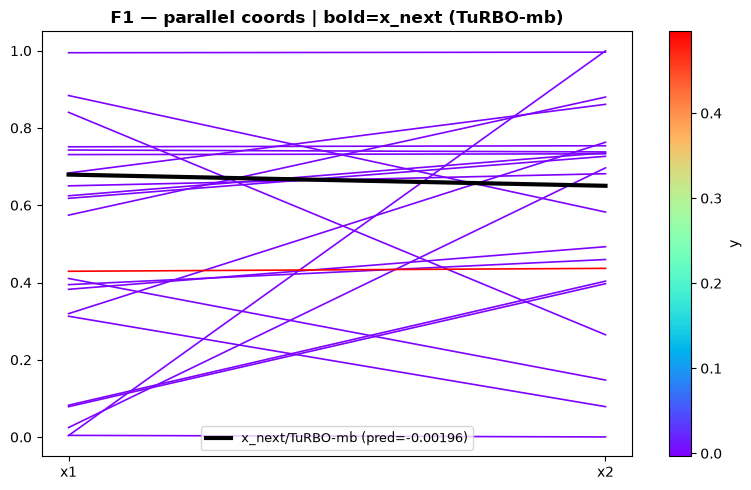

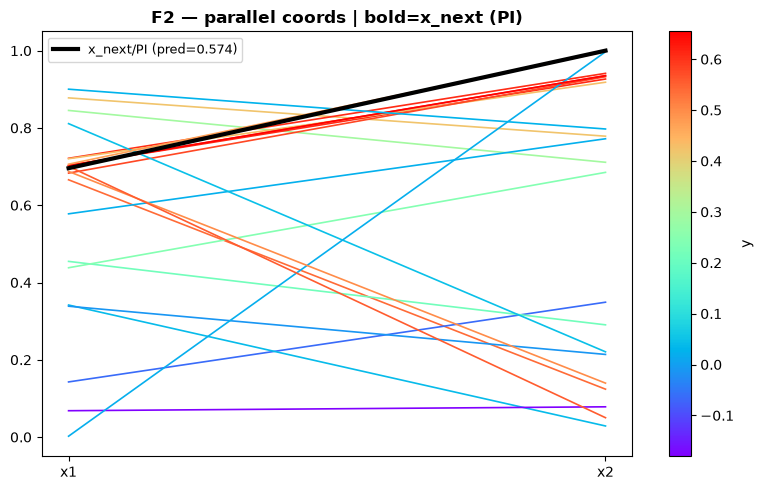

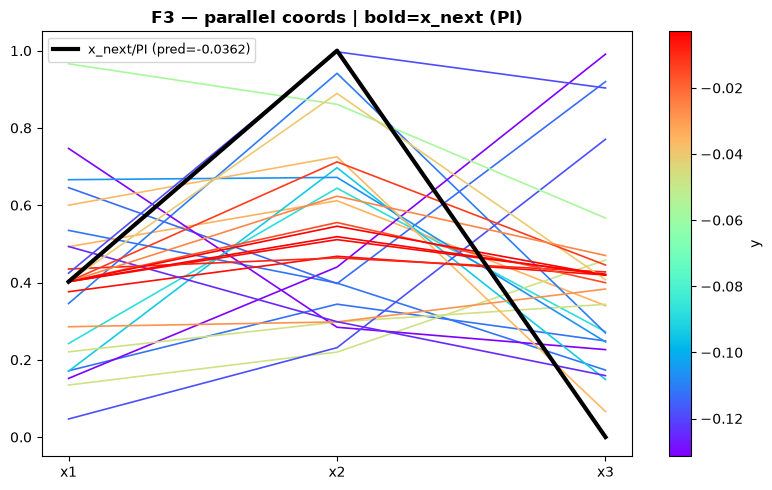

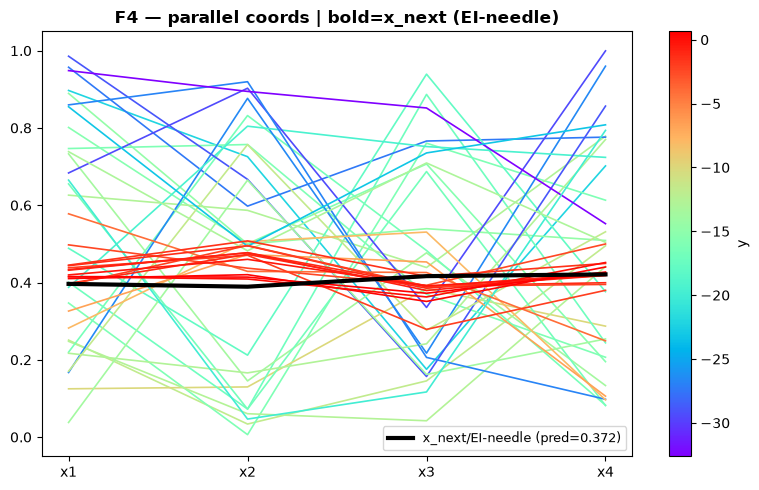

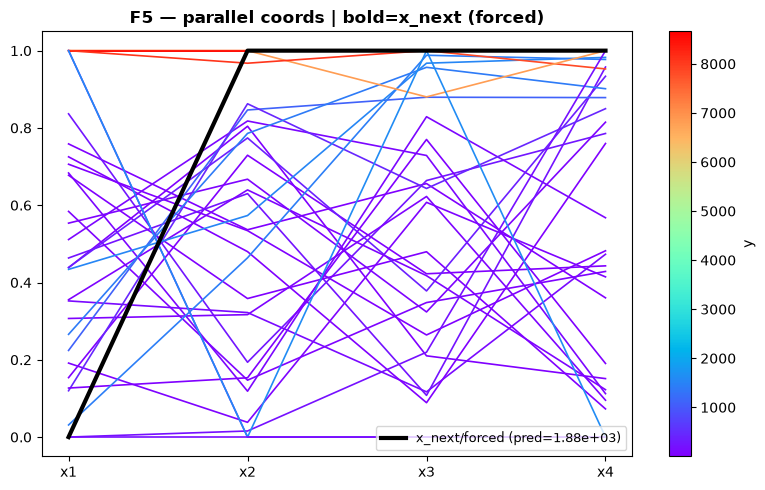

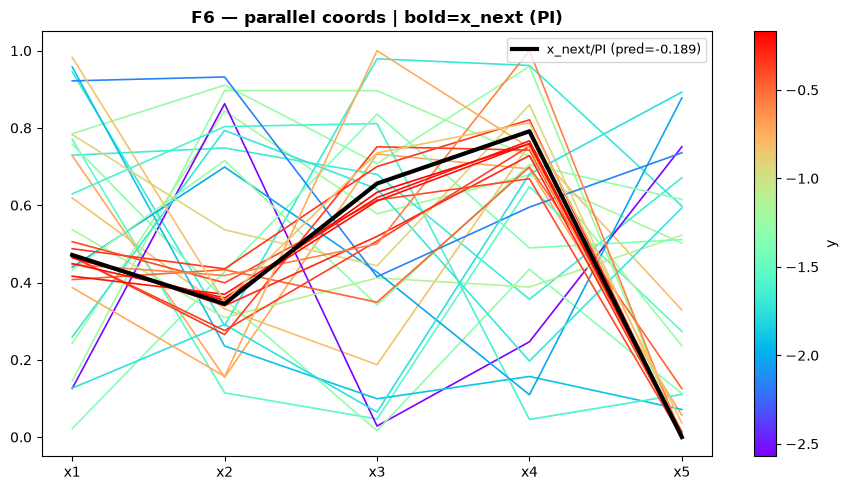

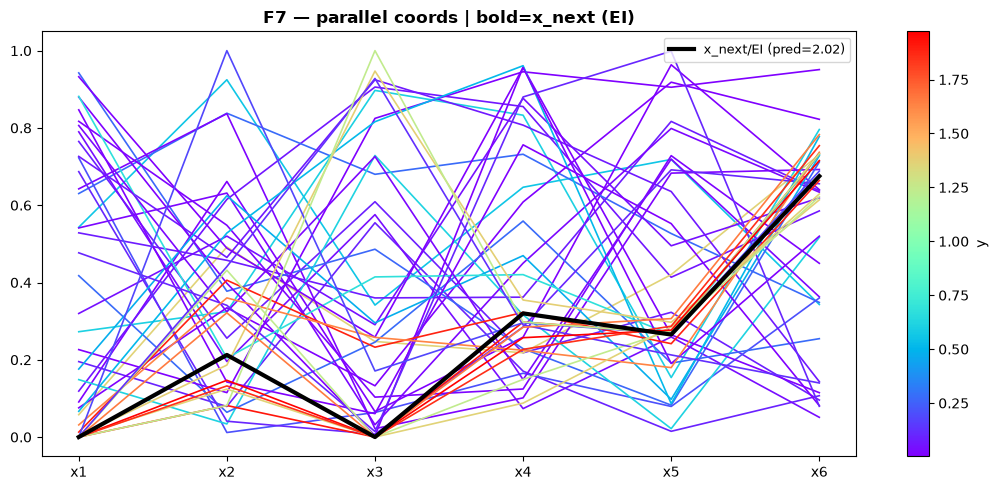

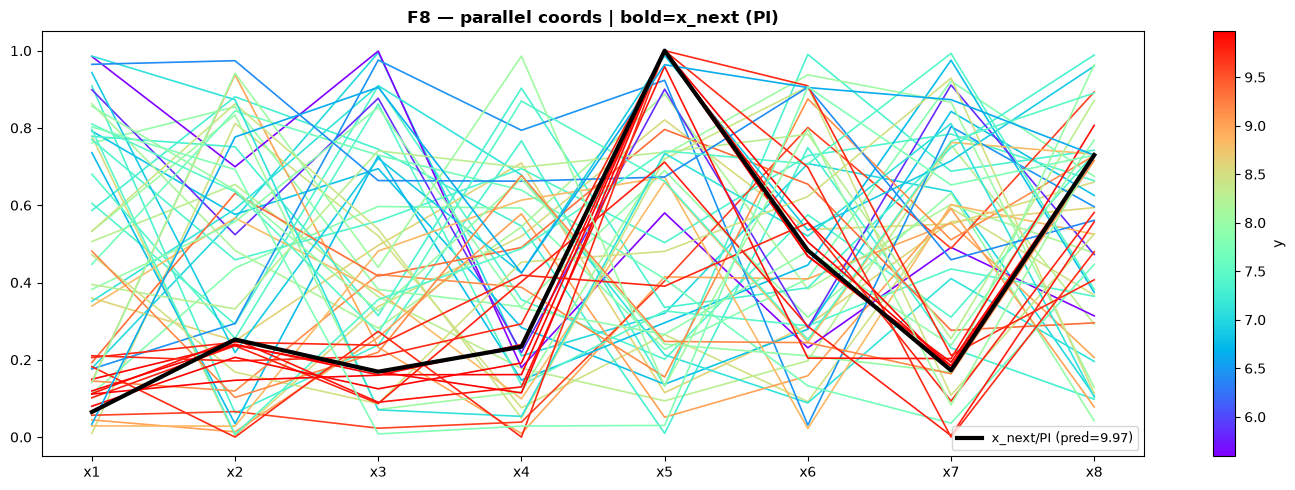

In [24]:
bdiag.plot_all_parallel(all_X, all_y, df_best, clip_bottom_fns=(3,))

## 6. Progress tracking

This section examines how the best value observed for each function has evolved over the course of the campaign, with the initial sampling phase excluded so that only the sequential decision-making phase is shown. F1 and F5 both exhibit a single large step improvement rather than gradual progress. F1's spike was discovered around rounds 10, and F5's vertex was discovered around round 3. F2, F3, F6, F7, and F8 have shown essentially no improvement over several recent rounds, which suggests these campaigns may be approaching their practical ceiling for the current evaluation budget.

Function           Best y    At idx
F1                 0.4962        21
F2                 0.6548        17
F3                -0.0029        26
F4                 0.6565        41
F5              8662.4050        24
F6                -0.1692        27
F7                 1.9734        40
F8                 9.9720        47


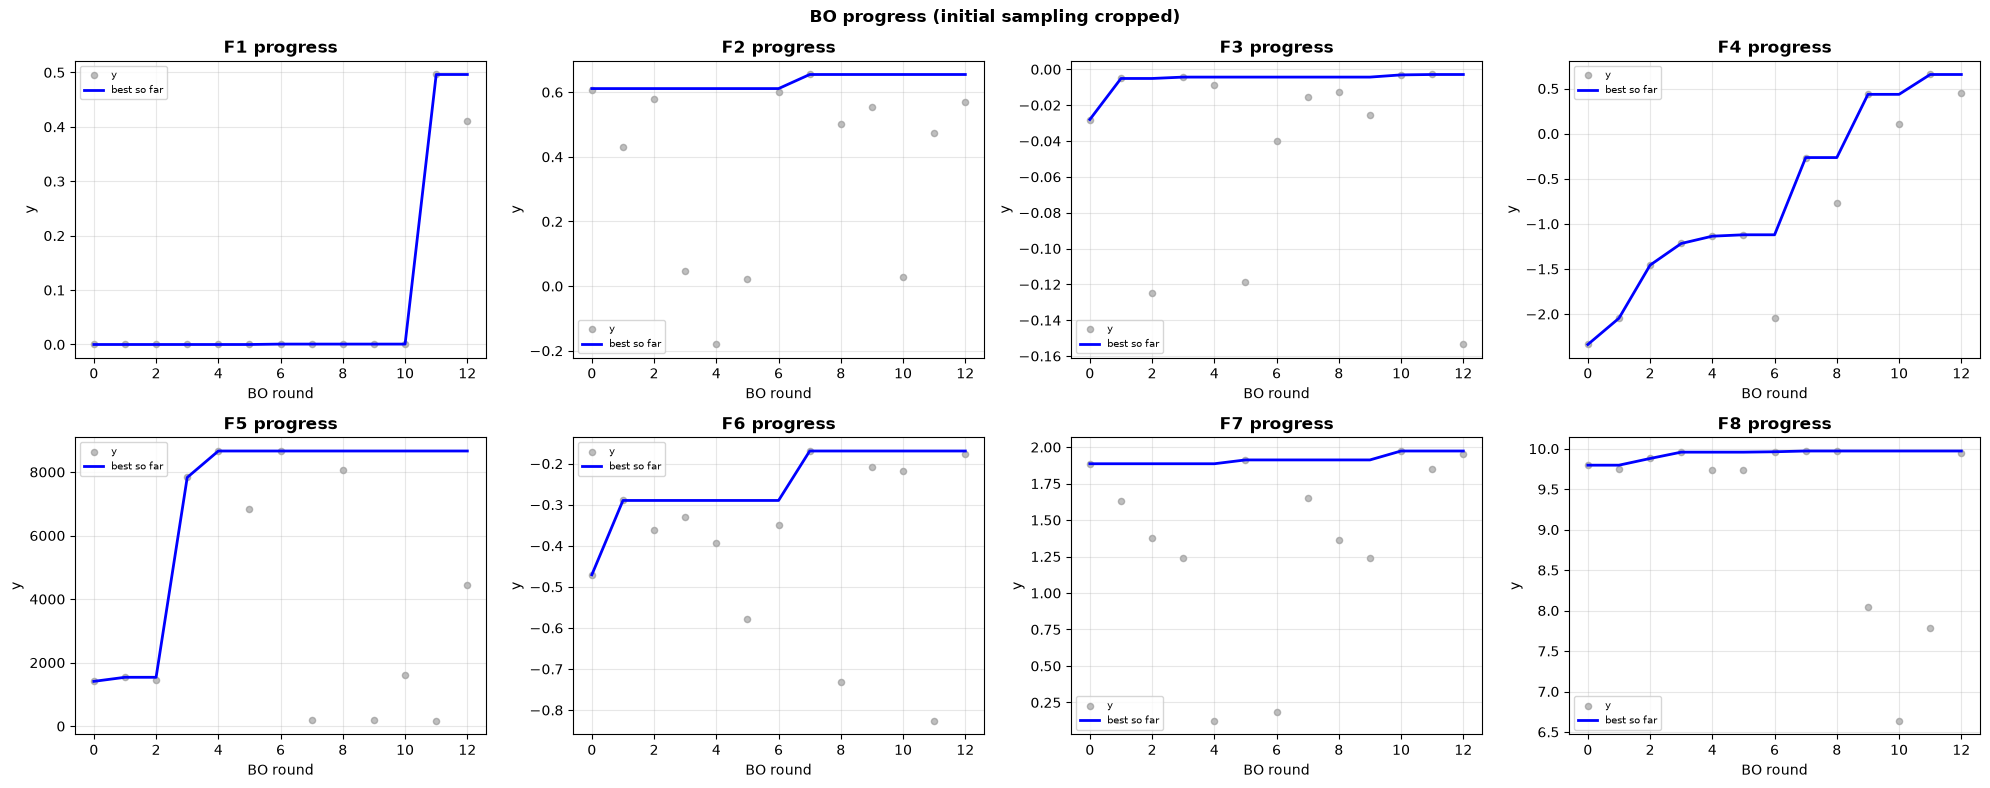

In [25]:
y_week_13 = [0.4114735617441124, 0.5694134426701808, -0.153560701901519, 0.4533179191682959, 4440.480873839292, -0.1759398370750595, 1.9540970220661815, 9.9519306176871]

for fn in range(1, 9):
    all_y[fn-1] = pd.concat([all_y[fn-1], pd.Series([y_week_13[fn-1]], name='y')], ignore_index=True)

bdiag.print_best_summary(all_y)

bdiag.plot_progress_grid(all_y)

F5's best value of 8662.4 exceeds every other function's best value by several orders of magnitude. This is a reminder that these are independent benchmark functions on unrelated scales, and that any summed or averaged score across functions would be meaningless without prior normalisation.

In [26]:

bdiag.print_best_summary(all_y)

Function           Best y    At idx
F1                 0.4962        21
F2                 0.6548        17
F3                -0.0029        26
F4                 0.6565        41
F5              8662.4050        24
F6                -0.1692        27
F7                 1.9734        40
F8                 9.9720        47
